# LinkedIn Job Postings – Data Mining Notebook

Notebook tổng hợp cho đồ án *Khai phá dữ liệu* với 3 câu hỏi nghiên cứu:

- **RQ1:** Phân cụm nhóm nghề nghiệp dựa trên mô tả công việc.
- **RQ2:** Khai phá các *skill bundles* (nhóm kỹ năng thường đi cùng nhau).
- **RQ3:** Phân tích & dự đoán mức lương dựa trên thông tin công việc.


# import libraries

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, mean_squared_error
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor


from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer

from sklearn.manifold import TSNE

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor


from mlxtend.preprocessing import TransactionEncoder
import networkx as nx
from networkx.algorithms.community import greedy_modularity_communities

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
sns.set(style="whitegrid", font_scale=1.1)


In [2]:
def normalize_text(s: str) -> str:
    s = str(s).lower()
    s = re.sub(r"[^a-z0-9+# ]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

# 1. Load & Tổng quan dữ liệu

## 1.1 Load data

In [3]:
# Đặt đúng đường dẫn file trước khi chạy
JOB_POSTINGS_PATH = "data/postings.csv"
COMPANIES_PATH = "data/companies.csv"
EMP_COUNTS_PATH = "data/employee_counts.csv"
JOB_SKILLS_PATH = "data/job_skills.csv"  
SKILL_MAP_PATH = "data/skill_mapping.csv" 

job_df = pd.read_csv(JOB_POSTINGS_PATH)
companies_df = pd.read_csv(COMPANIES_PATH)
emp_counts_df = pd.read_csv(EMP_COUNTS_PATH)
job_skills_df = pd.read_csv(JOB_SKILLS_PATH)
skill_map_df = pd.read_csv(SKILL_MAP_PATH)


In [4]:

# Gộp để lấy tên kỹ năng đầy đủ
job_skills_full = job_skills_df.merge(skill_map_df, on="skill_abr", how="left")

# Gom danh sách kỹ năng theo từng job_id
skills_per_job = (
    job_skills_full.dropna(subset=["skill_name"])
    .groupby("job_id")["skill_name"]
    .apply(list)
    .reset_index()
    .rename(columns={"skill_name": "linkedin_skills"})
)

In [5]:
job_df.head()

,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,...,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,...,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,...,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0


In [6]:
companies_df.head()

,company_id,name,description,company_size,state,country,city,zip_code,address,url
0,1009,IBM,"At IBM, we do more than work. We create. We cr...",7.0,NY,US,"Armonk, New York",10504,International Business Machines Corp.,https://www.linkedin.com/company/ibm
1,1016,GE HealthCare,Every day millions of people feel the impact o...,7.0,0,US,Chicago,0,-,https://www.linkedin.com/company/gehealthcare
2,1025,Hewlett Packard Enterprise,Official LinkedIn of Hewlett Packard Enterpris...,7.0,Texas,US,Houston,77389,1701 E Mossy Oaks Rd Spring,https://www.linkedin.com/company/hewlett-packa...
3,1028,Oracle,We’re a cloud technology company that provides...,7.0,Texas,US,Austin,78741,2300 Oracle Way,https://www.linkedin.com/company/oracle
4,1033,Accenture,Accenture is a leading global professional ser...,7.0,0,IE,Dublin 2,0,Grand Canal Harbour,https://www.linkedin.com/company/accenture


In [7]:
emp_counts_df.head()

,company_id,employee_count,follower_count,time_recorded
0,391906,186,32508,1712346173
1,22292832,311,4471,1712346173
2,20300,1053,6554,1712346173
3,3570660,383,35241,1712346173
4,878353,52,26397,1712346173


In [8]:
skills_per_job.head()

,job_id,linkedin_skills
0,921716,"[Marketing, Sales]"
1,1218575,[Health Care Provider]
2,1829192,[Health Care Provider]
3,2264355,"[Design, Art/Creative, Information Technology]"
4,10998357,"[Management, Manufacturing]"


## 1.2 Thống kê mô tả

### 1.2.1 Độ lớn dữ liệu

In [9]:
print(f"job_df: {job_df.shape}")
print(f"companies_df: {companies_df.shape}")
print(f"emp_counts_df: {emp_counts_df.shape}")
print(f"skills_per_job_df: {skills_per_job.shape}")

job_df: (123849, 31)
companies_df: (24473, 10)
emp_counts_df: (35787, 4)
skills_per_job_df: (126807, 2)


### 1.2.2 Thông tin kiểu dữ liệu của data

In [10]:
job_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123849 entries, 0 to 123848
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   job_id                      123849 non-null  int64  
 1   company_name                122130 non-null  object 
 2   title                       123849 non-null  object 
 3   description                 123842 non-null  object 
 4   max_salary                  29793 non-null   float64
 5   pay_period                  36073 non-null   object 
 6   location                    123849 non-null  object 
 7   company_id                  122132 non-null  float64
 8   views                       122160 non-null  float64
 9   med_salary                  6280 non-null    float64
 10  min_salary                  29793 non-null   float64
 11  formatted_work_type         123849 non-null  object 
 12  applies                     23320 non-null   float64
 13  original_liste

In [11]:
companies_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24473 entries, 0 to 24472
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   company_id    24473 non-null  int64  
 1   name          24472 non-null  object 
 2   description   24176 non-null  object 
 3   company_size  21699 non-null  float64
 4   state         24451 non-null  object 
 5   country       24473 non-null  object 
 6   city          24472 non-null  object 
 7   zip_code      24445 non-null  object 
 8   address       24451 non-null  object 
 9   url           24473 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 1.9+ MB


In [12]:
emp_counts_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35787 entries, 0 to 35786
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   company_id      35787 non-null  int64
 1   employee_count  35787 non-null  int64
 2   follower_count  35787 non-null  int64
 3   time_recorded   35787 non-null  int64
dtypes: int64(4)
memory usage: 1.1 MB


In [13]:
skills_per_job.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126807 entries, 0 to 126806
Data columns (total 2 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   job_id           126807 non-null  int64 
 1   linkedin_skills  126807 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.9+ MB


### 1.2.3 Thống kê mô tả

In [14]:

job_df.drop(columns="job_id").describe()

,max_salary,company_id,views,med_salary,min_salary,applies,original_listed_time,remote_allowed,expiry,closed_time,listed_time,sponsored,normalized_salary,zip_code,fips
count,2.979300e+04,1.221320e+05,122160.000000,6280.000000,2.979300e+04,23320.000000,1.238490e+05,15246.0,1.238490e+05,1.073000e+03,1.238490e+05,123849.0,3.607300e+04,102977.000000,96434.000000
mean,9.193942e+04,1.220401e+07,14.618247,22015.619876,6.491085e+04,10.591981,1.713152e+12,1.0,1.716213e+12,1.712928e+12,1.713204e+12,0.0,2.053270e+05,50400.491887,28713.879887
std,7.011101e+05,2.554143e+07,85.903598,52255.873846,4.959738e+05,29.047395,4.848209e+08,0.0,2.321394e+09,3.622893e+08,3.989122e+08,0.0,5.097627e+06,30252.232515,16015.929825
min,1.000000e+00,1.009000e+03,1.000000,0.000000,1.000000e+00,1.000000,1.701811e+12,1.0,1.712903e+12,1.712346e+12,1.711317e+12,0.0,0.000000e+00,1001.000000,1003.000000
25%,4.828000e+01,1.435200e+04,3.000000,18.940000,3.700000e+01,1.000000,1.712863e+12,1.0,1.715481e+12,1.712670e+12,1.712886e+12,0.0,5.200000e+04,24112.000000,13121.000000
50%,8.000000e+04,2.269650e+05,4.000000,25.500000,6.000000e+04,3.000000,1.713395e+12,1.0,1.716042e+12,1.712670e+12,1.713408e+12,0.0,8.150000e+04,48059.000000,29183.000000
75%,1.400000e+05,8.047188e+06,8.000000,2510.500000,1.000000e+05,8.000000,1.713478e+12,1.0,1.716088e+12,1.713283e+12,1.713484e+12,0.0,1.250000e+05,78201.000000,42077.000000
max,1.200000e+08,1.034730e+08,9975.000000,750000.000000,8.500000e+07,967.000000,1.713573e+12,1.0,1.729125e+12,1.713562e+12,1.713573e+12,0.0,5.356000e+08,99901.000000,56045.000000


In [15]:
companies_df.describe()

,company_id,company_size
count,2.447300e+04,21699.000000
mean,2.052239e+07,3.349233
std,3.165929e+07,1.904503
min,1.009000e+03,1.000000
25%,1.654040e+05,2.000000
50%,2.738154e+06,3.000000
75%,2.624142e+07,5.000000
max,1.034730e+08,7.000000


In [16]:
emp_counts_df.describe()

,company_id,employee_count,follower_count,time_recorded
count,3.578700e+04,35787.000000,3.578700e+04,3.578700e+04
mean,1.668254e+07,6715.874256,2.012616e+05,1.713163e+09
std,2.924722e+07,29400.984643,1.114733e+06,3.990869e+05
min,1.009000e+03,0.000000,0.000000e+00,1.712346e+09
25%,6.059650e+04,56.000000,2.738000e+03,1.712861e+09
50%,1.339209e+06,418.000000,1.617800e+04,1.713393e+09
75%,1.544092e+07,2945.000000,7.412950e+04,1.713472e+09
max,1.034730e+08,751125.000000,3.270284e+07,1.713573e+09


## 1.3 Tích hợp dữ liệu

In [17]:
# Merge job với thông tin công ty
job_merged = job_df.merge(companies_df, on="company_id", how="left")

# Sau khi merge, có thể xuất hiện description_x (job) và description_y (company)
# Chuẩn hóa lại để luôn có đúng một cột 'description' cho mô tả job
desc_cols = [c for c in job_merged.columns if "description" in c]
if "description" not in job_merged.columns:
    # Ưu tiên description_x nếu có (từ job_df)
    if "description_x" in job_merged.columns:
        job_merged["description"] = job_merged["description_x"]
    elif len(desc_cols) > 0:
        job_merged["description"] = job_merged[desc_cols[0]]
# Xóa các cột description trùng lặp khác (giữ lại 'description')
for c in desc_cols:
    if c != "description":
        job_merged.drop(columns=[c], inplace=True)

# Lấy bản ghi employee_count mới nhất cho mỗi công ty
emp_latest = emp_counts_df.sort_values("time_recorded").groupby("company_id").tail(1)
job_merged = job_merged.merge(
    emp_latest[["company_id", "employee_count", "follower_count"]],
    on="company_id",
    how="left",
)

# Merge skill vào job_merged
job_merged = job_merged.merge(skills_per_job, on="job_id", how="left")

print("Kích thước sau khi merge:", job_merged.shape)
job_merged.head()

Kích thước sau khi merge: (123849, 42)


,job_id,company_name,title,max_salary,pay_period,location,company_id,views,med_salary,min_salary,...,state,country,city,zip_code_y,address,url,description,employee_count,follower_count,linkedin_skills
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,17.0,...,NJ,US,Jersey City,07302,242 Tenth Street,https://www.linkedin.com/company/corcoran-sawy...,Job descriptionA leading real estate firm in N...,402.0,2351.0,"[Marketing, Sales]"
1,1829192,NaN,Mental Health Therapist/Counselor,50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,30.0,...,NaN,NaN,NaN,NaN,NaN,NaN,"At Aspen Therapy and Wellness , we are committ...",NaN,NaN,[Health Care Provider]
2,10998357,The National Exemplar,Assitant Restaurant Manager,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,45000.0,...,Ohio,US,Mariemont,45227,6880 Wooster Pike,https://www.linkedin.com/company/the-national-...,The National Exemplar is accepting application...,15.0,40.0,"[Management, Manufacturing]"
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,140000.0,...,New York,US,Lake Success,11042,3 Dakota Drive,https://www.linkedin.com/company/abrams-fenste...,Senior Associate Attorney - Elder Law / Trusts...,222.0,2427.0,[Other]
4,35982263,NaN,Service Technician,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,60000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Looking for HVAC service tech with experience ...,NaN,NaN,[Information Technology]


# 2. EDA – Khám phá dữ liệu

## 2.1 Tỷ lệ thiếu dữ liệu theo cột quan trọng

Tỷ lệ missing (theo %):


med_salary                    94.93
remote_allowed                87.69
min_salary                    75.94
max_salary                    75.94
formatted_experience_level    23.75
company_size                   5.42
employee_count                 1.39
country                        1.39
description                    0.01
title                          0.00
location                       0.00
dtype: float64

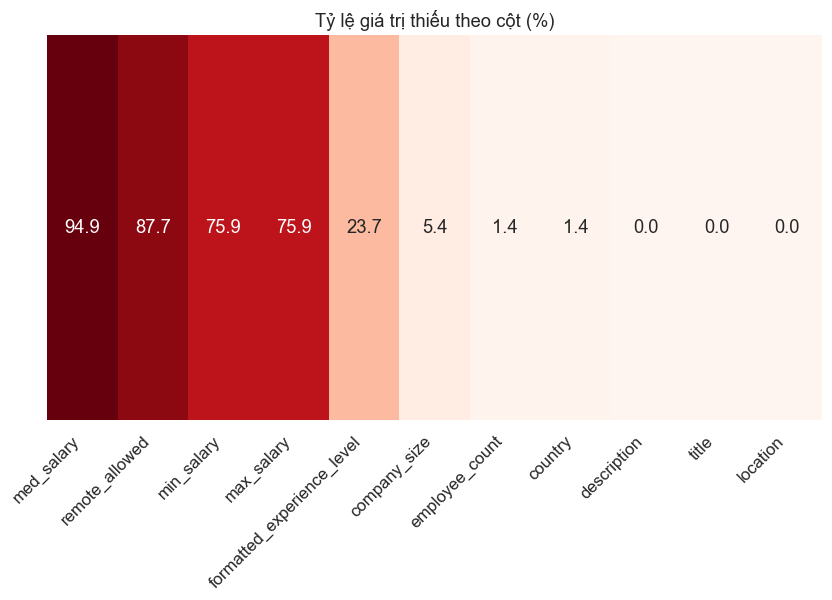

In [18]:
cols_check = [
    "title",
    "description",
    "min_salary",
    "med_salary",
    "max_salary",
    "formatted_experience_level",
    "remote_allowed",
    "location",
    "company_size",
    "employee_count",
    "country",
]

missing_ratio = job_merged[cols_check].isna().mean().sort_values(ascending=False)
print("Tỷ lệ missing (theo %):")
display((missing_ratio * 100).round(2))

# Vẽ heatmap tỷ lệ missing
sns.heatmap(
    missing_ratio.to_frame().T * 100, annot=True, fmt=".1f", cmap="Reds", cbar=False
)
plt.title("Tỷ lệ giá trị thiếu theo cột (%)")
plt.yticks([])
plt.xticks(rotation=45,ha="right")
plt.show()

## 2.2 Phân phối median salary

In [19]:
salary_cols = ["min_salary", "med_salary", "max_salary"]
for c in salary_cols:
    job_merged[c] = pd.to_numeric(job_merged[c], errors="coerce")

salary_nonnull = job_merged[salary_cols].dropna()
print("Số dòng có đủ min/med/max_salary:", len(salary_nonnull))

if len(salary_nonnull) > 0:
    sns.histplot(salary_nonnull["med_salary"], bins=40, kde=True, color="steelblue")
    plt.xlabel("Median salary")
    plt.ylabel("Số lượng job")
    plt.title("Phân phối median salary")
    plt.show()

Số dòng có đủ min/med/max_salary: 0


## 2.3 Lương theo cấp bậc kinh nghiệm

Số job có med_salary > 0: 6266


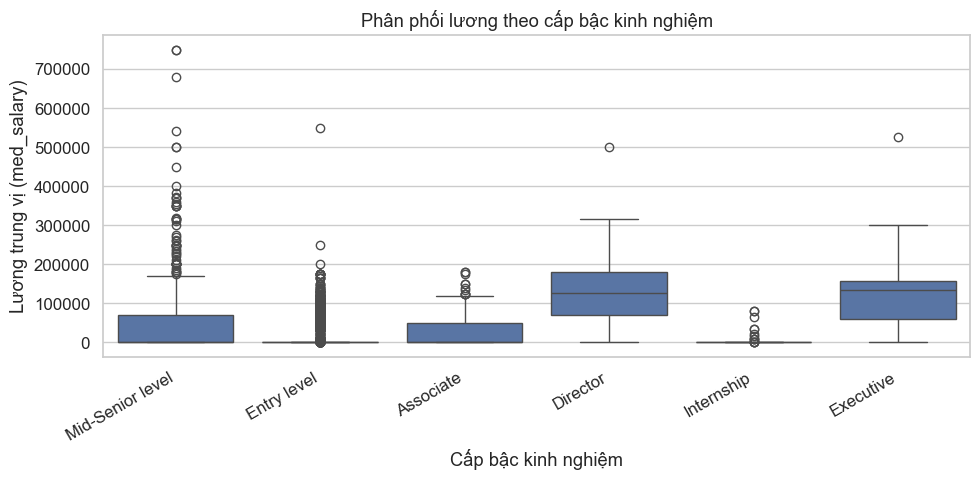

In [20]:
exp_order = job_merged["formatted_experience_level"].value_counts().index

# Lọc các bản ghi có lương dương
salary_cols = ["min_salary", "med_salary", "max_salary"]
salary_df = job_merged.dropna(subset=["med_salary"]).copy()
salary_df = salary_df[salary_df["med_salary"] > 0]

print("Số job có med_salary > 0:", len(salary_df))

sns.boxplot(
    data=salary_df,
    x="formatted_experience_level",
    y="med_salary",
    order=exp_order
)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Lương trung vị (med_salary)")
plt.xlabel("Cấp bậc kinh nghiệm")
plt.title("Phân phối lương theo cấp bậc kinh nghiệm")
plt.tight_layout()
plt.show()

## 2.4 Top quốc gia

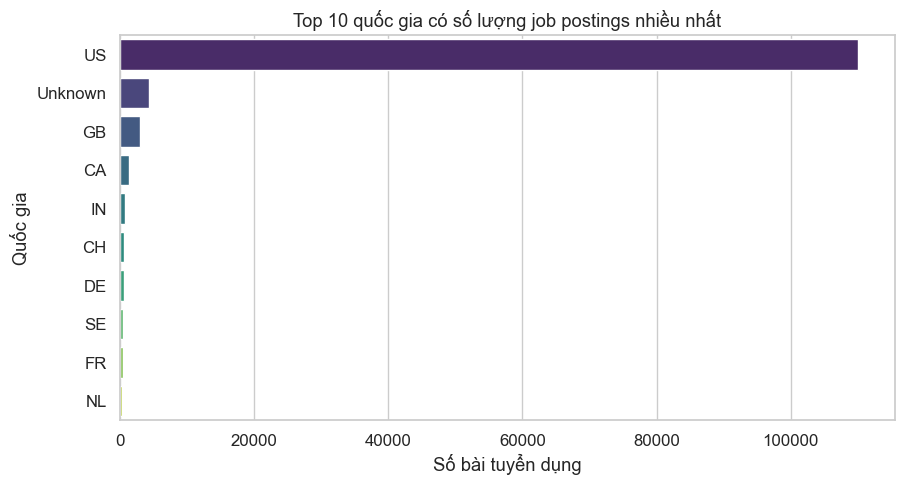

In [21]:
# do bộ dữ liệu quy ước 0 là nan nên ta phải chuyển đổi nó sang nan cho dễ xử lí
job_merged["country"].replace("0", np.nan, inplace=True)
job_merged["country"].fillna("Unknown", inplace=True)
# 2.4 Top quốc gia và thành phố có bài tuyển dụng nhiều nhất
top_countries = job_merged["country"].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette="viridis", hue=top_countries.index,legend=False)
plt.xlabel("Số bài tuyển dụng")
plt.ylabel("Quốc gia")
plt.title("Top 10 quốc gia có số lượng job postings nhiều nhất")
plt.show()


## 2.5 Top thành phố

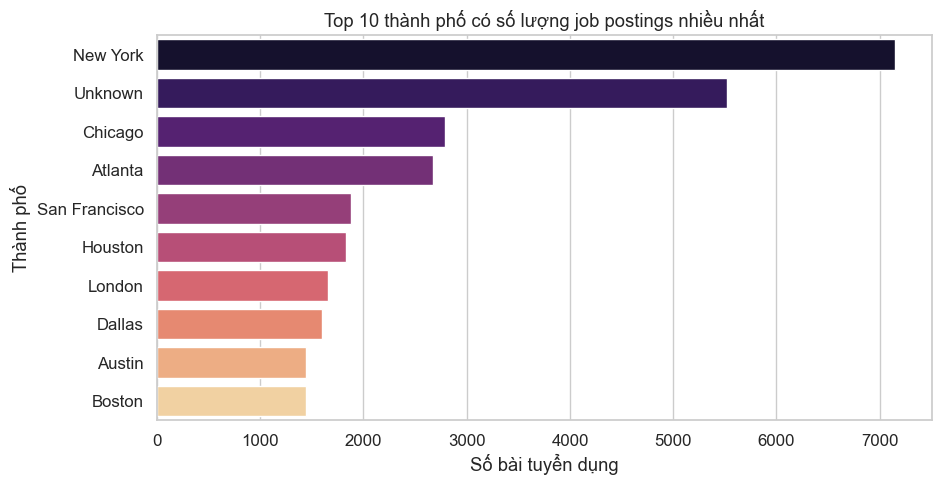

In [22]:
job_merged["city"].replace("0", np.nan, inplace=True)
job_merged["city"].fillna("Unknown", inplace=True)
top_cities = job_merged["city"].value_counts().head(10)
sns.barplot(x=top_cities.values, y=top_cities.index, palette="magma", hue=top_cities.index, legend=False)
plt.xlabel("Số bài tuyển dụng")
plt.ylabel("Thành phố")
plt.title("Top 10 thành phố có số lượng job postings nhiều nhất")
plt.show()

## 2.6 Mối quan hệ giữa lượt xem (views) và lượt ứng tuyển (applies)

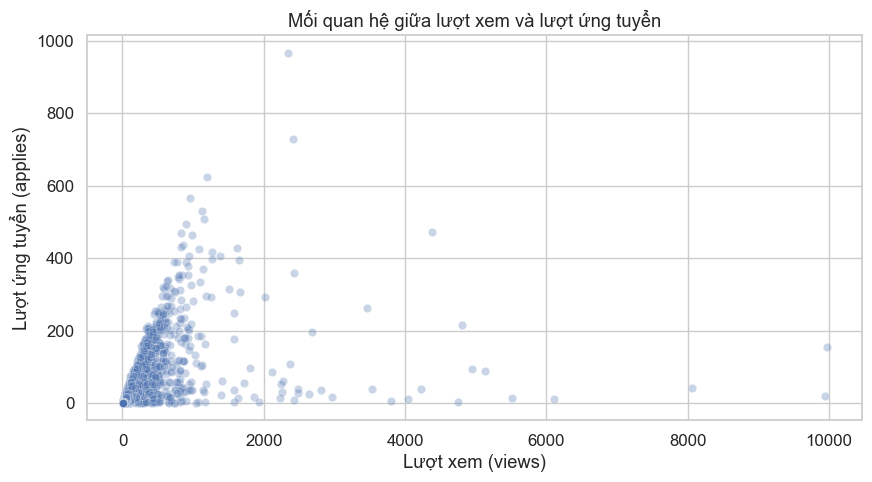

In [23]:
sns.scatterplot(data=job_merged, x="views", y="applies", alpha=0.3)
plt.xlabel("Lượt xem (views)")
plt.ylabel("Lượt ứng tuyển (applies)")
plt.title("Mối quan hệ giữa lượt xem và lượt ứng tuyển")
plt.show()

## 2.7 Phân phối độ dài mô tả công việc

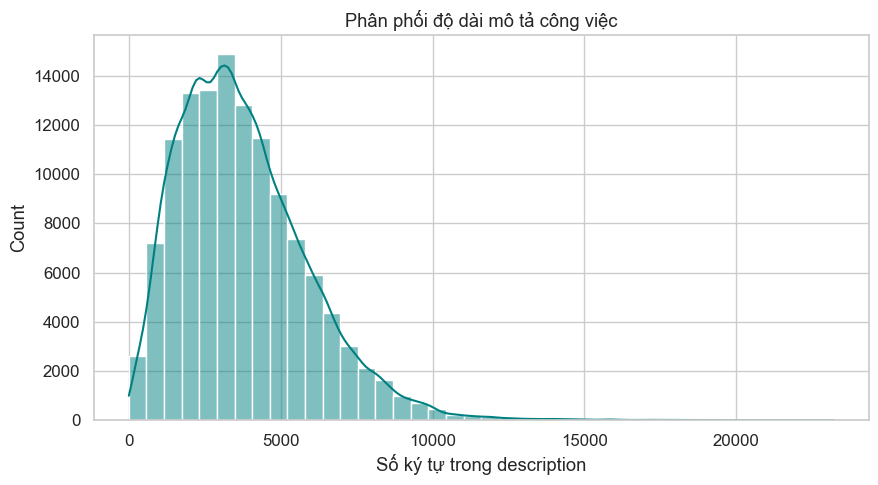

In [24]:
job_merged["desc_len"] = (
    job_merged["description"].fillna("").apply(lambda x: len(str(x)))
)

sns.histplot(job_merged["desc_len"], bins=40, kde=True, color="teal")
plt.xlabel("Số ký tự trong description")
plt.title("Phân phối độ dài mô tả công việc")
plt.show()

## 2.8 Phân phối lương (linear + log)

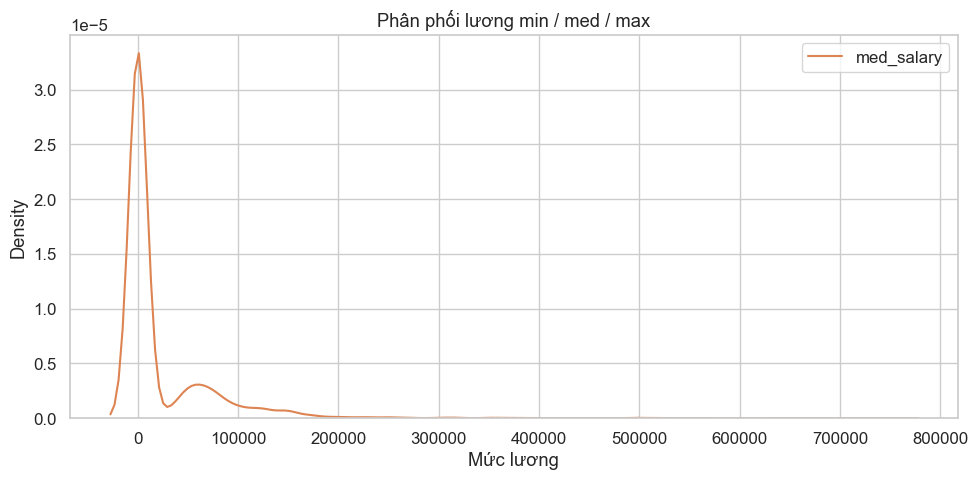

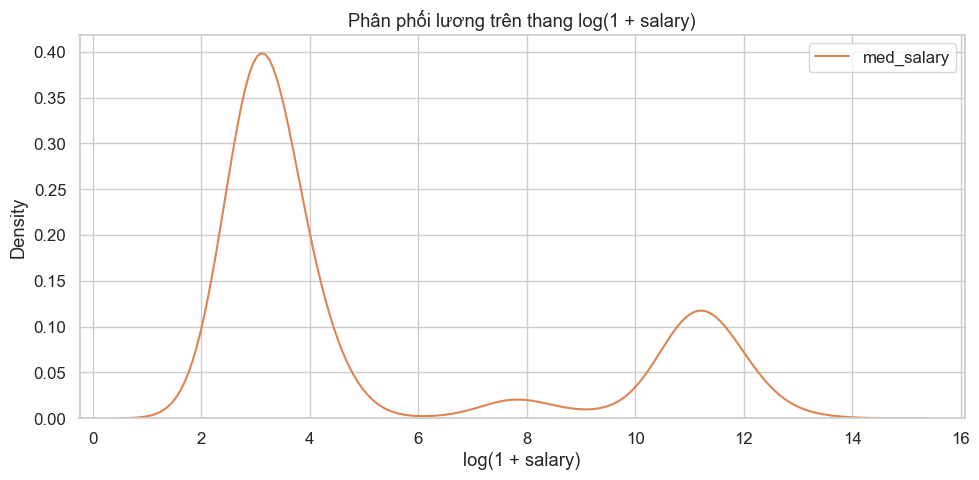

In [25]:
for col, color in zip(salary_cols, ["#6baed6", "#2171b5", "#9ecae1"]):
    sns.kdeplot(salary_df[col].dropna(), label=col, linewidth=1.5)
plt.xlabel("Mức lương")
plt.title("Phân phối lương min / med / max")
plt.legend()
plt.tight_layout()
plt.show()

# Phân phối trên thang log để xem rõ phần đuôi
for col, color in zip(salary_cols, ["#6baed6", "#2171b5", "#9ecae1"]):
    sns.kdeplot(np.log1p(salary_df[col].dropna()), label=col, linewidth=1.5)
plt.xlabel("log(1 + salary)")
plt.title("Phân phối lương trên thang log(1 + salary)")
plt.legend()
plt.tight_layout()
plt.show()

## 2.9 Độ dài mô tả theo cấp bậc kinh nghiệm

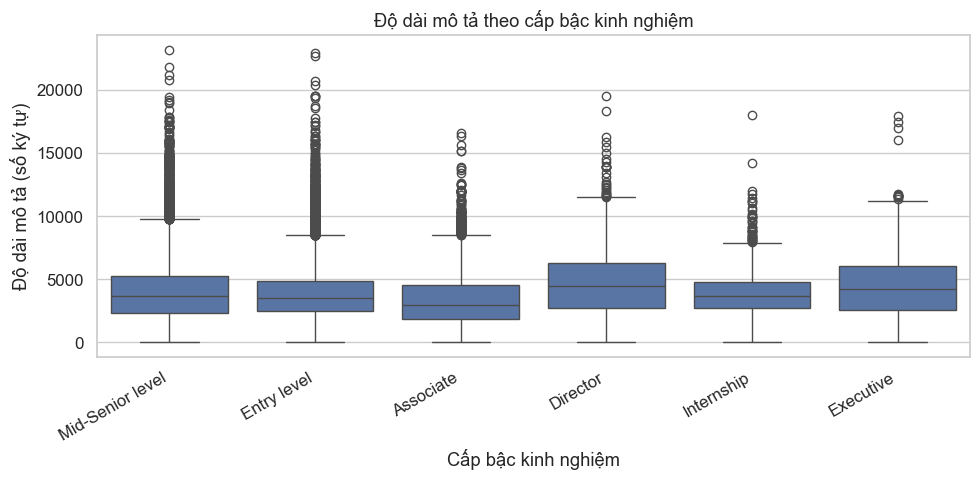

In [26]:
sns.boxplot(
    data=job_merged,
    x="formatted_experience_level",
    y="desc_len",
    order=exp_order
)
plt.xticks(rotation=30, ha="right")
plt.xlabel("Cấp bậc kinh nghiệm")
plt.ylabel("Độ dài mô tả (số ký tự)")
plt.title("Độ dài mô tả theo cấp bậc kinh nghiệm")
plt.tight_layout()
plt.show()

## 2.10 Độ dài mô tả theo loại hình làm việc

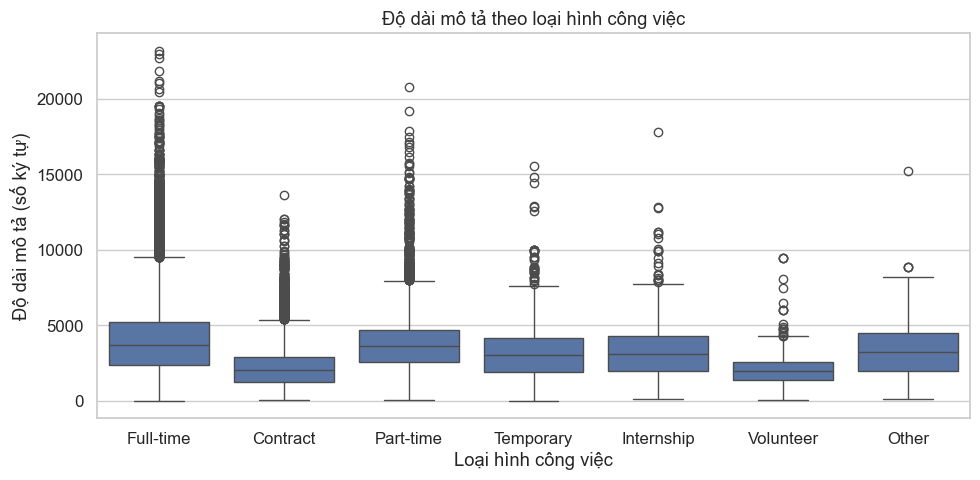

In [27]:
type_order = job_merged["formatted_work_type"].value_counts().index
sns.boxplot(
    data=job_merged,
    x="formatted_work_type",
    y="desc_len",
    order=type_order
)
plt.xlabel("Loại hình công việc")
plt.ylabel("Độ dài mô tả (số ký tự)")
plt.title("Độ dài mô tả theo loại hình công việc")
plt.tight_layout()
plt.show()

## 2.11 Top kỹ năng

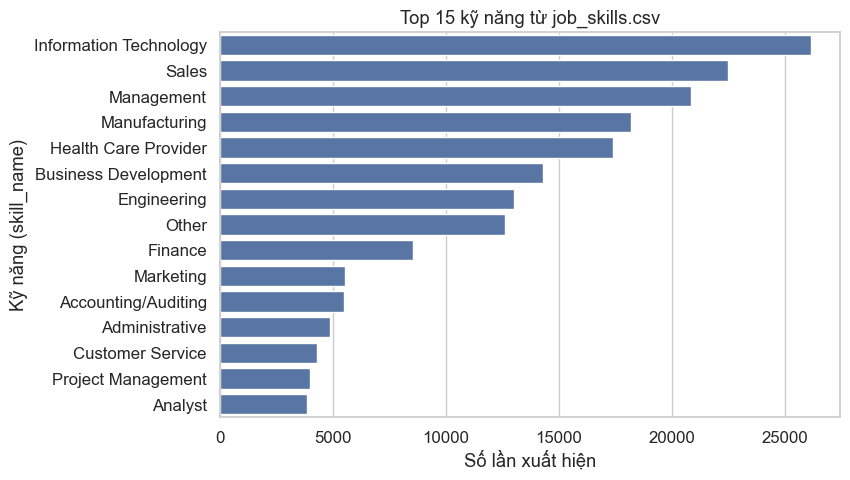

In [28]:
skills_full = job_skills_df.merge(skill_map_df, on="skill_abr", how="left")

top_skill_names = skills_full["skill_name"].value_counts().head(15)
plt.figure(figsize=(8, 5))
sns.barplot(x=top_skill_names.values, y=top_skill_names.index)
plt.xlabel("Số lần xuất hiện")
plt.ylabel("Kỹ năng (skill_name)")
plt.title("Top 15 kỹ năng từ job_skills.csv")
plt.show()

# 3. RQ1 – Phân cụm nhóm nghề nghiệp dựa trên mô tả công việc

### 3.1 Chuẩn bị dữ liệu văn bản cho mô hình phân cụm

Trong bước này, chúng tôi tiến hành xây dựng tập dữ liệu đầu vào dùng cho bài toán phân cụm mô tả công việc (RQ1). Mục tiêu của bước tiền xử lý là lựa chọn các trường thông tin cần thiết, loại bỏ các bản ghi thiếu dữ liệu và tối ưu kích thước tập dữ liệu nhằm đảm bảo quá trình vector hóa và phân cụm được thực hiện hiệu quả.

Cụ thể, chúng tôi chọn ba thành phần chính của mỗi bài đăng tuyển dụng: **job_id**, **title**, và **description**. Trường *job_id* hỗ trợ việc liên kết và truy xuất dữ liệu ở các bước sau, trong khi *title* giúp diễn giải và gán nhãn các cụm được tạo ra. Trường *description* đóng vai trò là nguồn dữ liệu văn bản chính để xây dựng mô hình TF–IDF và các kỹ thuật biểu diễn văn bản khác.

Nếu dữ liệu đã bao gồm cột *linkedin_skills* (được tạo từ việc merge với bảng kỹ năng), chúng tôi cũng giữ lại nhằm phục vụ phân tích kỹ năng và diễn giải cụm (liên quan RQ2).

Ngoài ra, do kích thước dữ liệu gốc khá lớn, chúng tôi áp dụng sampling với mức tối đa 20.000 bài đăng. Việc này giúp giảm chi phí tính toán, đồng thời vẫn giữ được tính đa dạng nội dung trong tập mẫu. Cuối cùng, chúng tôi loại bỏ tất cả các bài đăng không có mô tả công việc nhằm đảm bảo chất lượng đầu vào cho mô hình.

Bảng dữ liệu sau khi xử lý được dùng làm đầu vào cho các bước tiền xử lý văn bản và mô hình phân cụm ở phần tiếp theo.


In [29]:
TEXT_COL = "description"

# Giữ luôn job_id (và linkedin_skills nếu đã có) để join sau này
cols = ["job_id", "title", TEXT_COL]
if "linkedin_skills" in job_merged.columns:
    cols.append("linkedin_skills")

job_text = job_merged[cols].dropna(subset=[TEXT_COL]).copy()

MAX_DOCS = 20000
if len(job_text) > MAX_DOCS:
    job_text_sample = job_text.sample(MAX_DOCS, random_state=42)
else:
    job_text_sample = job_text

print("Số job dùng cho clustering:", len(job_text_sample))
job_text_sample.head()


Số job dùng cho clustering: 20000


,job_id,title,description,linkedin_skills
73457,3902931205,Warehouse,"Warehouse Associate\n\nSince 2022, Associated ...","[Management, Manufacturing]"
31563,3894855473,Influencer Talent Manager - Beauty,Interested in joining our influencer talent ma...,NaN
41620,3899525675,Talent Attraction Specialist,Talent Specialist - Hybrid Role Must be locate...,[Human Resources]
10762,3887106339,Retail Sales - Shoes - Stonebriar Centre,The ideal Salesperson is passionate about fash...,"[Sales, Customer Service]"
30334,3894555810,"Physician Assistant, Per Diem - Internal Medicine",1126363_RR00090444 Job ID: 1126363_RR00090444\...,[Other]


### 3.2 Biểu diễn văn bản bằng TF–IDF

Sau khi thu được tập dữ liệu mô tả công việc đã được làm sạch, bước tiếp theo là chuyển đổi văn bản thành dạng số để phục vụ cho các thuật toán phân cụm. Trong nghiên cứu này, chúng tôi sử dụng **TF–IDF (Term Frequency–Inverse Document Frequency)**, một kỹ thuật phổ biến cho phép đo lường mức độ quan trọng tương đối của một từ trong một văn bản so với toàn bộ tập tài liệu.

Mô hình TF–IDF được thiết lập với các tham số chính:

- **max_features = 20,000**: giới hạn số lượng đặc trưng nhằm cân bằng giữa độ chi tiết của không gian biểu diễn và chi phí tính toán.
- **ngram_range = (1, 2)**: sử dụng cả đơn từ (*unigram*) và cụm hai từ (*bigram*), giúp mô hình nắm bắt tốt hơn các cụm ngữ nghĩa như “data analyst”, “machine learning”, “project management”.
- **stop_words = "english"**: loại bỏ các từ dừng trong tiếng Anh, giảm nhiễu và tăng tính phân biệt giữa các mô tả công việc.

Sau khi thiết lập vectorizer, chúng tôi tiến hành khởi tạo lại chỉ mục dữ liệu và áp dụng `fit_transform` lên trường *description*. Kết quả thu được là ma trận TF–IDF kích thước *(số bài đăng × số đặc trưng)*, là đầu vào trực tiếp cho mô hình phân cụm ở các bước tiếp theo.


In [30]:
# TF-IDF vectorizer
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), stop_words="english")
job_text_sample = job_text_sample.reset_index(drop=True)

X_text = tfidf.fit_transform(job_text_sample[TEXT_COL])
X_text.shape

(20000, 20000)

## 3.3 Thử nghiệm các giá trị *k*, tính chỉ số Silhouette & trực quan hóa kết quả

Trong bước này, chúng tôi tiến hành đánh giá chất lượng phân cụm cho nhiều giá trị *k* khác nhau của thuật toán K-Means. Mục tiêu là xác định số lượng cụm phù hợp nhất với cấu trúc dữ liệu mô tả công việc.

Chúng tôi lựa chọn tập giá trị *k* = {4, 6, 8, 10, 12, 15}, bao phủ từ mức phân cụm tổng quát (k nhỏ) đến mức phân rã chi tiết hơn (k lớn). Với mỗi giá trị *k*, mô hình K-Means được huấn luyện với tham số `n_init = 10` nhằm tăng độ ổn định của kết quả.

Sau khi mô hình gán nhãn cho toàn bộ dữ liệu, chúng tôi sử dụng chỉ số **Silhouette** để đo lường chất lượng phân cụm. Chỉ số này phản ánh:

- **Độ cô đặc** của các điểm trong cùng một cụm  
- **Độ tách biệt** giữa các cụm khác nhau

Giá trị Silhouette càng cao cho thấy cấu trúc phân cụm càng rõ ràng. Kết quả cho từng giá trị *k* được in ra màn hình và lưu vào một dictionary để phục vụ bước trực quan hóa và phân tích tiếp theo.

Biểu đồ dùng để trực quan hóa kết quả.


k=4, silhouette=0.0087
k=6, silhouette=0.0094
k=8, silhouette=0.0120
k=10, silhouette=0.0144
k=12, silhouette=0.0148
k=15, silhouette=0.0154


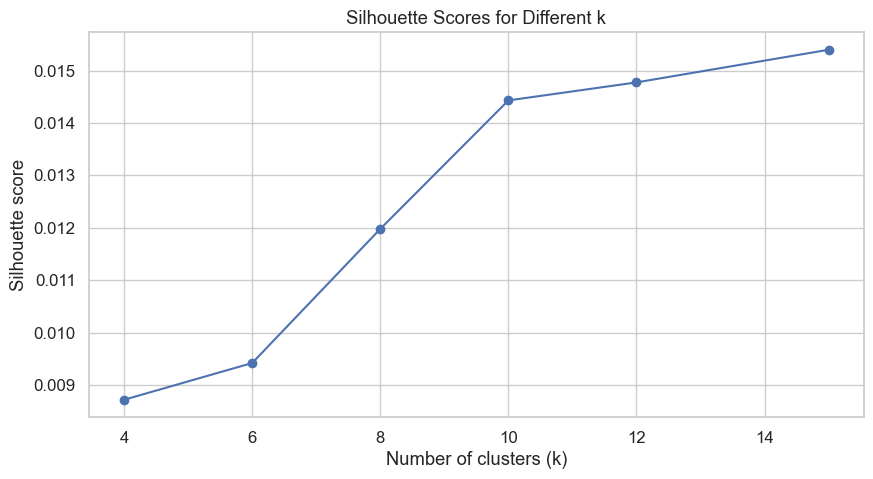

In [31]:
# Tập giá trị k được đề xuất
k_values = [4, 6, 8, 10, 12, 15]

sil_scores = {}

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_text)
    score = silhouette_score(X_text, labels)
    sil_scores[k] = score
    print(f"k={k}, silhouette={score:.4f}")

# Vẽ biểu đồ
plt.plot(list(sil_scores.keys()), list(sil_scores.values()), marker="o")
plt.title("Silhouette Scores for Different k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.grid(True)
plt.show()

## 3.4 Chạy với **k** có **silhouette** cao nhất

In [32]:
# Chọn số cụm (ví dụ: k có silhouette cao nhất)
best_k = max(sil_scores, key=sil_scores.get)
print("Chọn số cụm:", best_k)

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
job_text_sample["cluster"] = kmeans.fit_predict(X_text)
# job_text_sample[["title", TEXT_COL, "cluster"]].head()
job_text_sample.head()

Chọn số cụm: 15


,job_id,title,description,linkedin_skills,cluster
0,3902931205,Warehouse,"Warehouse Associate\n\nSince 2022, Associated ...","[Management, Manufacturing]",0
1,3894855473,Influencer Talent Manager - Beauty,Interested in joining our influencer talent ma...,NaN,10
2,3899525675,Talent Attraction Specialist,Talent Specialist - Hybrid Role Must be locate...,[Human Resources],1
3,3887106339,Retail Sales - Shoes - Stonebriar Centre,The ideal Salesperson is passionate about fash...,"[Sales, Customer Service]",12
4,3894555810,"Physician Assistant, Per Diem - Internal Medicine",1126363_RR00090444 Job ID: 1126363_RR00090444\...,[Other],11


In [33]:
# Xem top từ đặc trưng cho mỗi cụm
def top_terms_per_cluster(model, vectorizer, n_terms=15):
    terms = np.array(vectorizer.get_feature_names_out())
    order_centroids = model.cluster_centers_.argsort()[:, ::-1]
    cluster_terms = {}
    for i in range(model.n_clusters):
        top_terms = terms[order_centroids[i, :n_terms]]
        cluster_terms[i] = top_terms
    return cluster_terms


cluster_keywords = top_terms_per_cluster(kmeans, tfidf, n_terms=15)
cluster_keywords

{0: array(['work', 'equipment', 'safety', 'required', 'job', 'ability',
        'service', 'food', 'duties', 'perform', 'company', 'customer',
        'able', 'time', 'maintenance'], dtype=object),
 1: array(['status', 'experience', 'work', 'employment', 'business',
        'benefits', 'team', 'information', 'gender', 'including', 'job',
        'position', 'disability', 'employees', 'management'], dtype=object),
 2: array(['accounting', 'financial', 'tax', 'finance', 'reporting',
        'accountant', 'experience', 'accounts', 'degree accounting',
        'analysis', 'business', 'monthly', 'accounting finance',
        'financial reporting', 'team'], dtype=object),
 3: array(['galt', 'earnings', 'credit', 'business', 'sales', 'personal',
        'figure', 'memberships', 'business owners', 'saas', 'owners',
        'executive consultants', 'state trade', 'earnings expectations',
        '25 executive'], dtype=object),
 4: array(['sales', 'customer', 'business', 'customers', 'new', 'exp

In [34]:
# Số lượng job trong mỗi cụm
job_text_sample["cluster"].value_counts().sort_index()

cluster
0     2296
1     2971
2      688
3       96
4     1264
5     4276
6      666
7       86
8      245
9      249
10     589
11    1955
12    1169
13    1390
14    2060
Name: count, dtype: int64

## 3.5 Trực quan hóa kết quả

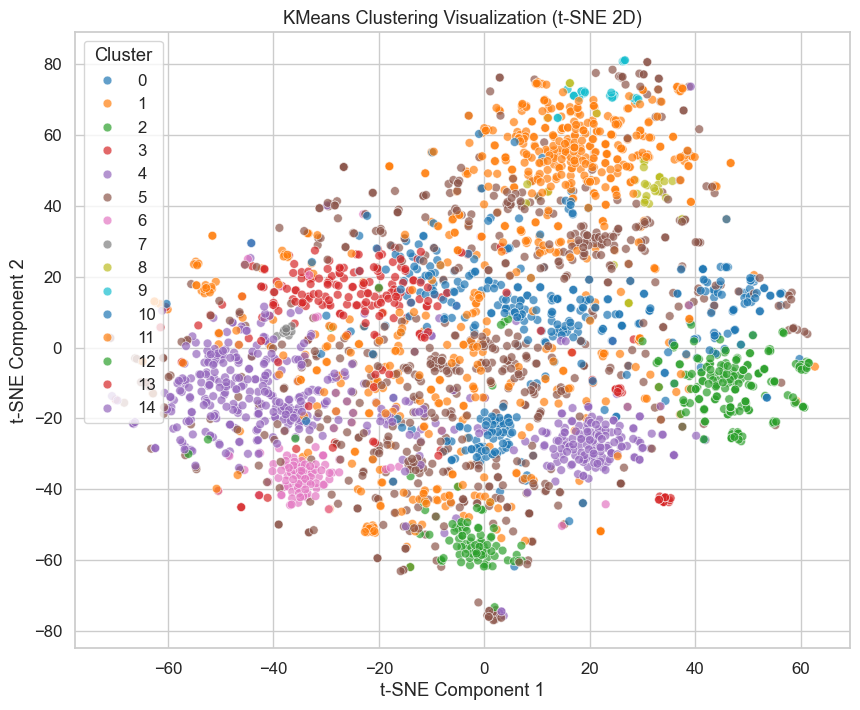

In [35]:

# Lấy mẫu nhỏ để vẽ t-SNE cho đẹp
N = 3000
job_vis = job_text_sample.sample(N, random_state=42)
X_vis = X_text[job_vis.index]

tsne = TSNE(n_components=2, perplexity=40, learning_rate=200, random_state=42)
X_tsne = tsne.fit_transform(X_vis.toarray())

job_vis["tsne1"] = X_tsne[:, 0]
job_vis["tsne2"] = X_tsne[:, 1]

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=job_vis, x="tsne1", y="tsne2", hue="cluster", palette="tab10", alpha=0.7, s=40
)

plt.title("KMeans Clustering Visualization (t-SNE 2D)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(title="Cluster")
plt.show()


## 3.6 Biểu đồ so sánh RQ1 Clusters vs LinkedIn Skill Map

Số job có cả cluster và linkedin_skills: 19704


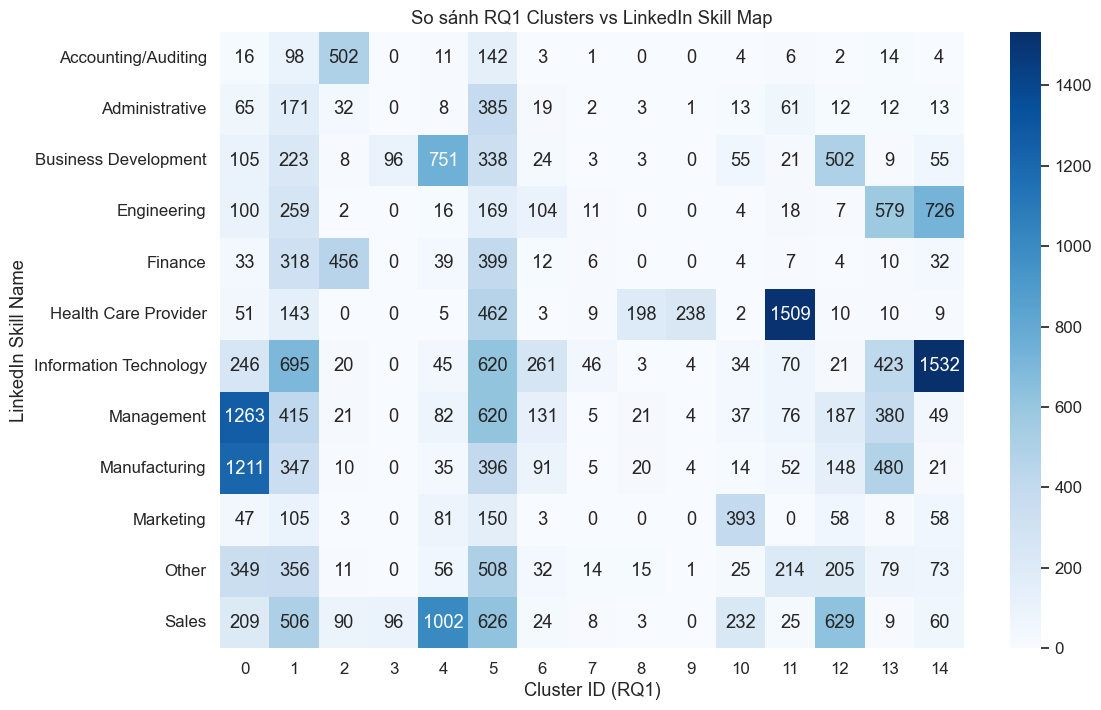

In [36]:
# Chỉ lấy job có linkedin_skills
df = job_text_sample.dropna(subset=["linkedin_skills"]).copy()
print("Số job có cả cluster và linkedin_skills:", len(df))

rows = []
for _, row in df.iterrows():
    c = row["cluster"]
    for skill in row["linkedin_skills"]:
        rows.append((c, skill))

compare_df = pd.DataFrame(rows, columns=["cluster", "skill_name"])

TOP_N = 12
top_skills = compare_df["skill_name"].value_counts().head(TOP_N).index
filtered_df = compare_df[compare_df["skill_name"].isin(top_skills)]

pivot = filtered_df.pivot_table(
    index="skill_name", columns="cluster", aggfunc="size", fill_value=0
)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=True, fmt="d", cmap="Blues")
plt.title("So sánh RQ1 Clusters vs LinkedIn Skill Map")
plt.xlabel("Cluster ID (RQ1)")
plt.ylabel("LinkedIn Skill Name")
plt.show()


# 4. RQ2 – Khai phá *Skill Bundles* từ ESCO Ontology

## 4.1. Load & làm sạch ESCO skills (skill_en.csv) 

In [37]:
ESCO_SKILL_PATH = "data/skills_en.csv"
esco = pd.read_csv(ESCO_SKILL_PATH)
esco_raw = esco["preferredLabel"].dropna().astype(str)
esco_norm = esco_raw.apply(normalize_text)


def is_valid_skill(term: str) -> bool:
    term = term.strip()
    if len(term) < 3:
        return False
    if term.isdigit():
        return False
    if len(term.split()) > 5:
        return False
    return True


esco_clean = esco_norm[esco_norm.apply(is_valid_skill)].drop_duplicates()
esco_skills = esco_clean.tolist()
print("Số ESCO skills sau khi làm sạch:", len(esco_skills))
esco_skills[:20]

Số ESCO skills sau khi làm sạch: 12280


['manage musical staff',
 'supervise correctional procedures',
 'apply anti oppressive practices',
 'identify available services',
 'perform toxicological studies',
 'ensure coquille uniformity',
 'haskell',
 'show initiative',
 'apply diplomatic principles',
 'lead police investigations',
 'handle fish harvesting waste',
 'develop energy saving concepts',
 'work with soloists',
 'sport and exercise medicine',
 'conduct research on flora',
 'install heat pump',
 'design biomass installations',
 'handle equipment while suspended',
 'teach housekeeping skills',
 'check train engines']

## 4.2. Vector hóa n-gram từ mô tả công việc

**Khai phá n-gram từ toàn bộ mô tả công việc**

Để phục vụ cho các phân tích ngôn ngữ nâng cao và nhận diện các cụm từ (phrase) phổ biến trong mô tả công việc, chúng tôi tiến hành trích xuất n-gram từ toàn bộ trường *description*. Trước tiên, văn bản được chuẩn hóa thông qua hàm `normalize_text`, nhằm đảm bảo tính nhất quán giữa các mô tả.

Do kích thước dữ liệu lớn, chúng tôi giới hạn tối đa 80.000 dòng khi huấn luyện mô hình n-gram. Việc lấy mẫu này giúp giảm chi phí tính toán nhưng vẫn duy trì được sự đa dạng của ngôn ngữ trong tập dữ liệu.

Quá trình trích xuất n-gram sử dụng **CountVectorizer** với các thiết lập:

- **ngram_range = (1, 4)**: trích xuất unigram, bigram, trigram và four-gram, cho phép phát hiện cả các cụm từ ngữ dài liên quan đến kỹ năng hoặc mô tả nhiệm vụ.
- **min_df = 15**: chỉ giữ lại các n-gram xuất hiện ít nhất 15 lần, giúp loại bỏ nhiễu và từ hiếm.
- **max_df = 0.85**: loại bỏ các n-gram xuất hiện quá phổ biến, tránh các cụm từ ít mang tính phân biệt.
- **token_pattern** được điều chỉnh để cho phép giữ lại các token chứa ký tự số, ký tự đặc biệt như `+` hoặc `#` (ví dụ: *c++*, *c#*, *python3*).
- **stop_words = "english"** nhằm loại bỏ các từ dừng không mang ý nghĩa phân tích.

Sau khi vectorizer được huấn luyện trên mẫu dữ liệu, chúng tôi lấy danh sách toàn bộ n-gram xuất hiện trong tập mô tả công việc và in ra tổng số lượng n-gram thu được. Các n-gram này có thể được sử dụng cho phân tích kỹ năng nâng cao, phát hiện phrase đặc trưng theo cụm hoặc xây dựng từ điển kỹ năng tùy chỉnh.


In [38]:
desc_series_full = job_merged["description"].fillna("").apply(normalize_text)

MAX_ROWS_NGRAM = 80000
if len(desc_series_full) > MAX_ROWS_NGRAM:
    desc_sample = desc_series_full.sample(MAX_ROWS_NGRAM, random_state=42)
else:
    desc_sample = desc_series_full

vec_all = CountVectorizer(
    ngram_range=(1, 4),
    min_df=15,
    max_df=0.85,
    token_pattern=r"[a-z0-9+#]+",
    stop_words="english",
)
vec_all.fit(desc_sample)
ngrams_all = set(vec_all.get_feature_names_out())
print("Tổng số n-gram từ mô tả:", len(ngrams_all))

Tổng số n-gram từ mô tả: 643067


## 4.3. Giao giữa ESCO skills & n-gram trong dữ liệu

In [39]:
esco_set = set(esco_skills)
skill_vocab = sorted(list(esco_set & ngrams_all))
print("Số ESCO skills thực sự xuất hiện trong corpus:", len(skill_vocab))
skill_vocab[:30]

Số ESCO skills thực sự xuất hiện trong corpus: 751


['abap',
 'accounting',
 'accounting entries',
 'achieve sales targets',
 'acoustics',
 'actuarial science',
 'acute care',
 'adhesives',
 'adjust priorities',
 'adobe creative suite',
 'adobe illustrator',
 'adobe photoshop',
 'adult education',
 'advanced materials',
 'advocate health',
 'aerospace engineering',
 'aesthetics',
 'agile development',
 'agile project management',
 'agronomy',
 'ajax',
 'alarm systems',
 'algebra',
 'algorithms',
 'allergies',
 'alternative energy',
 'analytical chemistry',
 'angular',
 'animal nutrition',
 'animal welfare']

## 4.4. Ma trận doc x skill cho toàn bộ job

In [40]:
vec_skill = CountVectorizer(
    vocabulary=skill_vocab,
    ngram_range=(1, 4),
    binary=True,
    token_pattern=r"[a-z0-9+#]+",
)
X_skill = vec_skill.fit_transform(desc_series_full)
skill_names = np.array(vec_skill.get_feature_names_out())
print("Ma trận doc x skill:", X_skill.shape)

Ma trận doc x skill: (123849, 751)


In [41]:
# Tạo skills_list cho từng job
skills_list = []
for i in range(X_skill.shape[0]):
    idx = X_skill[i].nonzero()[1]
    skills = skill_names[idx].tolist()
    skills_list.append(skills)

job_merged["skills_list"] = skills_list
job_merged[["title", "skills_list"]].head(10)

,title,skills_list
0,Marketing Coordinator,"[genetics, graphic design, plan]"
1,Mental Health Therapist/Counselor,"[communication, crisis intervention, plan]"
2,Assitant Restaurant Manager,[]
3,Senior Elder Law / Trusts and Estates Associat...,[communication]
4,Service Technician,[]
5,Economic Development and Planning Intern,"[communication, economics, geography, public a..."
6,Producer,[motion graphics]
7,Building Engineer,"[building codes, communication, english, plan,..."
8,Respiratory Therapist,"[chemistry, control systems, plan, respiratory..."
9,Worship Leader,[team building]


## 4.5. Tính co-occurrence & lift

**Khai phá quan hệ đồng xuất hiện kỹ năng dựa trên ESCO (Association Analysis)**

Ở bước này, chúng tôi thực hiện phân tích đồng xuất hiện và mối quan hệ giữa các kỹ năng (skill association) dựa trên danh sách kỹ năng ESCO được gán cho từng bài đăng tuyển dụng. Mục tiêu là xác định các cặp kỹ năng thường đi cùng nhau trong thị trường lao động, qua đó khám phá các “skill bundles” phục vụ RQ2.

Trước tiên, chúng tôi lọc các bài đăng có ít nhất một kỹ năng ESCO. Sau đó, chúng tôi sử dụng `TransactionEncoder` để biến đổi mỗi bài đăng thành một vector nhị phân (0/1), biểu diễn sự có mặt của từng kỹ năng trong mô tả công việc.

Ma trận nhị phân thu được có kích thước (N × M), trong đó:
- **N** — số lượng bài đăng có kỹ năng ESCO,
- **M** — số kỹ năng ESCO xuất hiện trong dữ liệu.

Tiếp theo, chúng tôi tính:

- **Support (A)**: tỷ lệ bài đăng chứa kỹ năng A.
- **Support (A, B)**: tỷ lệ bài đăng chứa đồng thời kỹ năng A và B.
- **Confidence (A → B)**: xác suất xuất hiện B khi A xuất hiện.
- **Lift (A → B)**: mức độ tăng cường của mối quan hệ giữa A và B so với kỳ vọng ngẫu nhiên.  
  Lift > 1 cho thấy hai kỹ năng có xu hướng xuất hiện cùng nhau cao hơn mức ngẫu nhiên.

Tất cả cặp kỹ năng (A, B) được tính toán các chỉ số trên và lưu vào một bảng kết quả. Các cặp được sắp xếp theo giá trị **lift** giảm dần nhằm ưu tiên những quan hệ mạnh nhất, phản ánh các nhóm kỹ năng thường đi kèm nhau trong thực tế tuyển dụng.

Bảng kết quả gồm top 20 cặp kỹ năng có lift cao nhất cung cấp cơ sở quan trọng để nhận diện các cụm kỹ năng (skill bundles) và phục vụ cho bước phân tích mạng kỹ năng ở các phần tiếp theo.


In [42]:
skills_transactions = job_merged["skills_list"]
skills_transactions = skills_transactions[skills_transactions.map(len) > 0]
print("Số job có ít nhất 1 skill ESCO:", len(skills_transactions))

te = TransactionEncoder()
te_ary = te.fit(skills_transactions.tolist()).transform(skills_transactions.tolist())
skills_ohe = pd.DataFrame(te_ary, columns=te.columns_)

X_bin = skills_ohe.values
N = X_bin.shape[0]

support = X_bin.mean(axis=0)
co_matrix = (X_bin.T @ X_bin) / N

skills = skills_ohe.columns.tolist()
pairs = []
for i in range(len(skills)):
    for j in range(i + 1, len(skills)):
        supp_ij = co_matrix[i, j]
        if supp_ij == 0:
            continue
        supp_i = support[i]
        supp_j = support[j]
        conf = supp_ij / supp_i if supp_i > 0 else 0
        lift = conf / supp_j if supp_j > 0 else 0
        pairs.append(
            {
                "skill_A": skills[i],
                "skill_B": skills[j],
                "support_AB": supp_ij,
                "support_A": supp_i,
                "support_B": supp_j,
                "confidence": conf,
                "lift": lift,
            }
        )

rules_esco = pd.DataFrame(pairs).sort_values("lift", ascending=False)
rules_esco.head(20)

Số job có ít nhất 1 skill ESCO: 114796


,skill_A,skill_B,support_AB,support_A,support_B,confidence,lift
20407,control production,schedule production,0.000009,0.000122,0.000122,0.071429,585.693878
34494,financial engineering,satisfy customers,0.000009,0.000253,0.000070,0.034483,494.810345
33992,evaluate employees,food service operations,0.000009,0.000070,0.000270,0.125000,462.887097
10601,building materials industry,prospect new customers,0.000009,0.000200,0.000105,0.043478,415.927536
40425,identify customer requirements,marketing mix,0.000009,0.000087,0.000244,0.100000,409.985714
11847,business management principles,prepare financial statements,0.000009,0.000044,0.000679,0.200000,294.348718
11851,business management principles,thermodynamics,0.000009,0.000044,0.000723,0.200000,276.616867
13687,chemical processes,control production,0.000009,0.000261,0.000122,0.033333,273.323810
9984,build networks,marine engineering,0.000009,0.000157,0.000209,0.055556,265.731481
20409,control production,smed,0.000009,0.000122,0.000296,0.071429,241.168067


## 4.6. Xây network graph skill bundles

In [43]:
TOP_EDGES = 60
top_rules = rules_esco.head(TOP_EDGES)

G = nx.Graph()
for _, r in top_rules.iterrows():
    G.add_edge(r["skill_A"], r["skill_B"], weight=r["lift"])

print("Nodes:", G.number_of_nodes(), "Edges:", G.number_of_edges())

communities = list(greedy_modularity_communities(G))
print("Số community:", len(communities))
for i, comm in enumerate(communities):
    print(f"Community {i} size={len(comm)} sample={list(comm)[:10]}")

Nodes: 78 Edges: 60
Số community: 21
Community 0 size=12 sample=['coach employees', 'conserve natural resources', 'smed', 'product data management', 'herbicides', 'irrigation systems', 'water consumption', 'chemical processes', 'control production', 'schedule production']
Community 1 size=7 sample=['sustainable manufacturing', 'mechanical tools', 'composite materials', 'test hardware', 'orthotics', 'wire harnesses', 'biomechanics']
Community 2 size=6 sample=['write technical reports', 'energy transformation', 'maintain laboratory equipment', 'collect samples', 'medical laboratory technology', 'organic chemistry']
Community 3 size=6 sample=['handle customer complaints', 'listen actively', 'handle complaints', 'education law', 'assess customers', 'process customer orders']
Community 4 size=6 sample=['evaluate employees', 'audiology', 'epidemiology', 'food service operations', 'trigonometry', 'dietetics']
Community 5 size=5 sample=['metalworking', 'environmental design', 'multidisciplinar

### 4.6.1 Vẽ network graph 

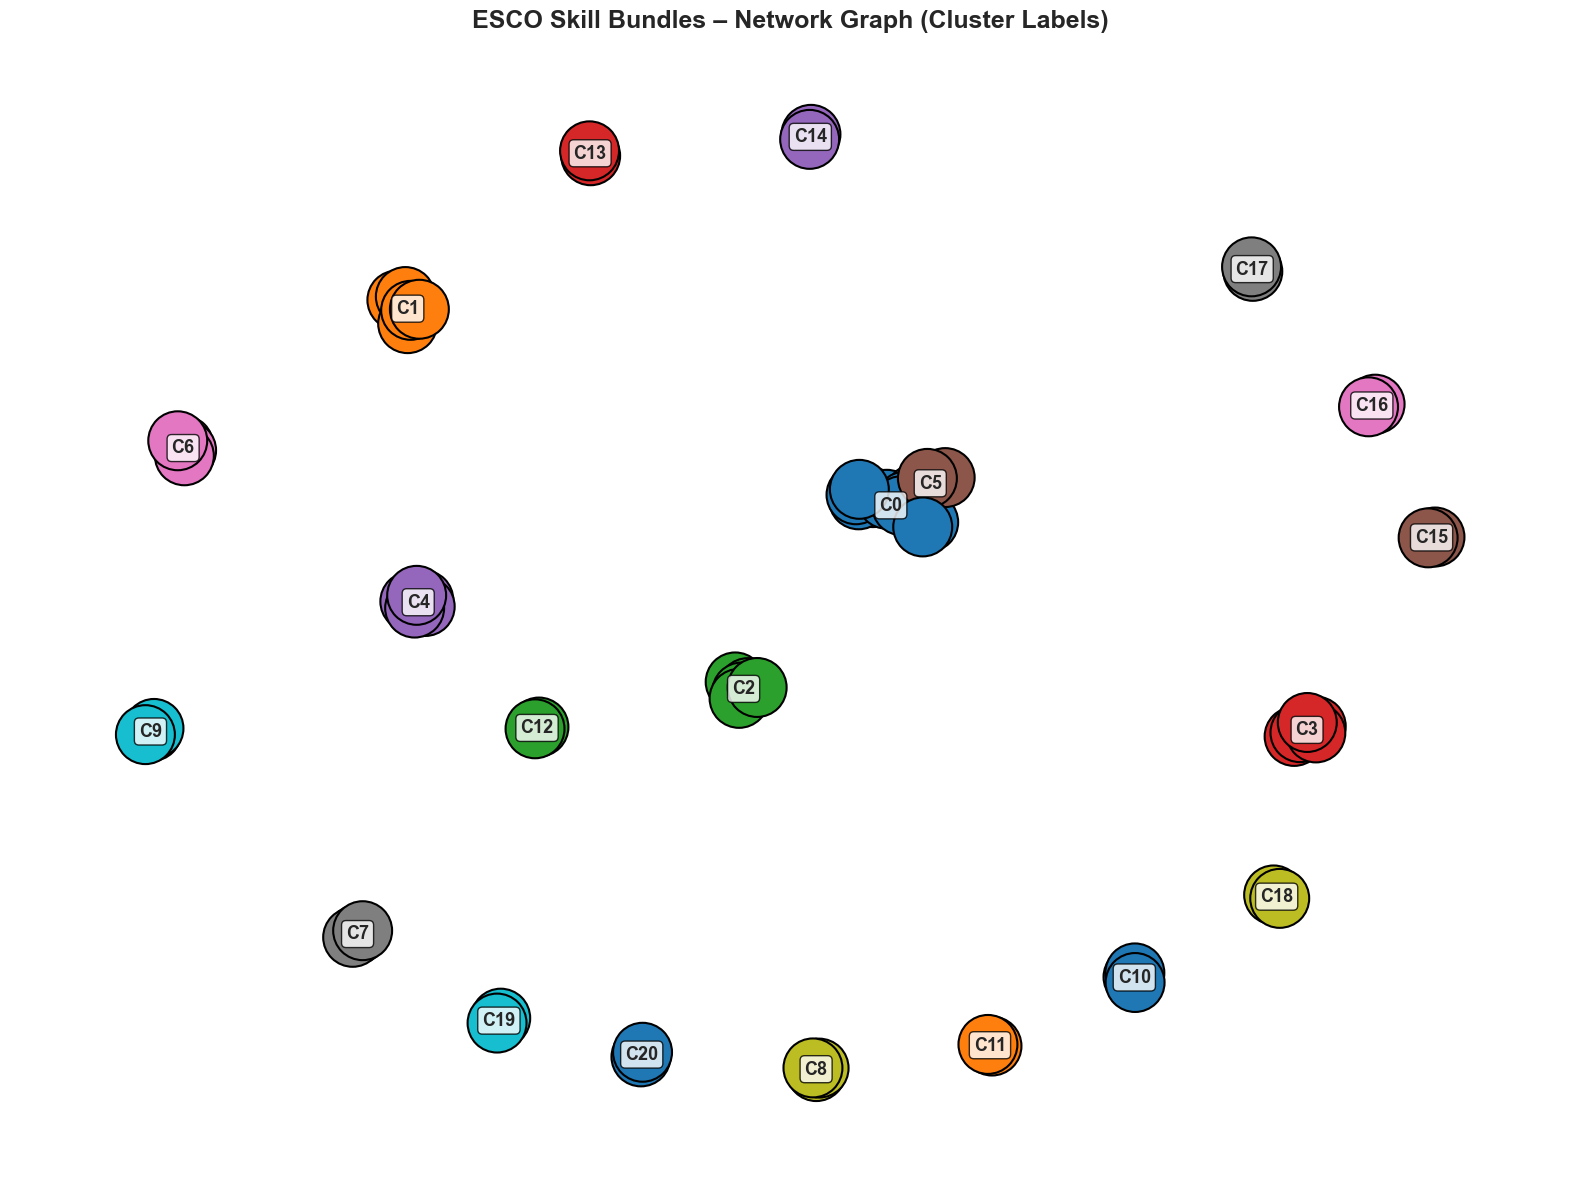

In [44]:
node2comm = {}
for cid, comm in enumerate(communities):
    for n in comm:
        node2comm[n] = cid

cmap = plt.get_cmap("tab10")
node_colors = [cmap(node2comm[n] % 10) for n in G.nodes()]

# Layout
pos = nx.spring_layout(G, k=1.3, iterations=500, seed=42)

plt.figure(figsize=(16, 12))

# Edge weights
edges = G.edges(data=True)
weights = np.array([d["weight"] for (_, _, d) in edges])
if len(weights) > 0:
    min_w, max_w = weights.min(), weights.max()
    if max_w > min_w:
        norm_w = 1 + 4 * (weights - min_w) / (max_w - min_w)
    else:
        norm_w = np.ones_like(weights)
else:
    norm_w = []

# Vẽ edges
nx.draw_networkx_edges(G, pos, edge_color="lightgray", width=norm_w, alpha=0.7)

# Vẽ nodes (có viền)
nx.draw_networkx_nodes(
    G, pos, node_color=node_colors, node_size=1800, edgecolors="black", linewidths=1.5
)

# ======= LABEL CHO MỖI CỤM =======
# Tính tâm (mean) vị trí các node trong từng cụm

cluster_centers = {}
for cid, comm in enumerate(communities):
    xs = [pos[n][0] for n in comm]
    ys = [pos[n][1] for n in comm]
    cluster_centers[cid] = (np.mean(xs), np.mean(ys))

# Vẽ 1 label tại tâm cụm
for cid, (x, y) in cluster_centers.items():
    plt.text(
        x,
        y,
        f"C{cid}",
        fontsize=13,
        fontweight="bold",
        ha="center",
        va="center",
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="black", alpha=0.8),
    )

plt.title(
    "ESCO Skill Bundles – Network Graph (Cluster Labels)",
    fontsize=18,
    fontweight="bold",
)
plt.axis("off")
plt.tight_layout()
plt.show()


### 4.6.2 Một số cụm kĩ năng tiêu biểu

In [45]:
# Tạo dict: community_id -> list skill (node)
community_dict = {
    cid: sorted(list(comm))  # sắp xếp cho dễ nhìn
    for cid, comm in enumerate(communities)
}

community_dict

{0: ['chemical processes',
  'coach employees',
  'conserve natural resources',
  'control engineering',
  'control production',
  'herbicides',
  'irrigation systems',
  'pesticides',
  'product data management',
  'schedule production',
  'smed',
  'water consumption'],
 1: ['biomechanics',
  'composite materials',
  'mechanical tools',
  'orthotics',
  'sustainable manufacturing',
  'test hardware',
  'wire harnesses'],
 2: ['collect samples',
  'energy transformation',
  'maintain laboratory equipment',
  'medical laboratory technology',
  'organic chemistry',
  'write technical reports'],
 3: ['assess customers',
  'education law',
  'handle complaints',
  'handle customer complaints',
  'listen actively',
  'process customer orders'],
 4: ['audiology',
  'dietetics',
  'epidemiology',
  'evaluate employees',
  'food service operations',
  'trigonometry'],
 5: ['collection management',
  'environmental design',
  'metalworking',
  'multidisciplinary research',
  'power engineering

Tạo nhãn

In [46]:
from sklearn.feature_extraction.text import TfidfVectorizer

auto_cluster_names = {}

for cid, skills in community_dict.items():
    doc = " ".join(skills)
    vectorizer = TfidfVectorizer(stop_words="english")
    tfidf = vectorizer.fit_transform([doc])

    scores = tfidf.toarray()[0]
    top_ids = np.argsort(scores)[::-1][:3]  # 3 từ mạnh nhất
    keywords = [vectorizer.get_feature_names_out()[i] for i in top_ids]

    auto_cluster_names[cid] = " / ".join(keywords)

auto_cluster_names

{0: 'production / control / smed',
 1: 'wire / tools / test',
 2: 'laboratory / write / technology',
 3: 'complaints / customer / handle',
 4: 'trigonometry / service / operations',
 5: 'research / power / multidisciplinary',
 6: 'virology / science / portfolio',
 7: 'thermodynamics / statements / principles',
 8: 'networks / naval / marine',
 9: 'trading / software / satisfy',
 10: 'techniques / sustainability / imaging',
 11: 'prospect / new / materials',
 12: 'requirements / mix / marketing',
 13: 'training / technical / provide',
 14: 'sql / services / server',
 15: 'systems / quality / language',
 16: 'talent / strategies / management',
 17: 'medicine / intubation / community',
 18: 'training / report / needs',
 19: 'pharmacokinetics / biophysics',
 20: 'students / disorders / communication'}

In [47]:
def plot_community(G, community, cid):
    subG = G.subgraph(list(community))

    pos = nx.spring_layout(subG, k=1.2, iterations=400, seed=42)
    plt.figure(figsize=(16, 12))

    nx.draw_networkx_nodes(
        subG, pos, node_size=2400, node_color="#4A90E2", edgecolors="black"
    )

    nx.draw_networkx_edges(subG, pos, width=2, alpha=0.7, edge_color="gray")

    nx.draw_networkx_labels(subG, pos, font_size=11, font_weight="bold")

    # plt.title(f"Skill Bundle Cluster {auto_cluster_names[cid]}", fontsize=16)
    plt.title(f"cluster {cid}: {auto_cluster_names[cid]}", fontsize=16)
    plt.axis("off")
    plt.show()


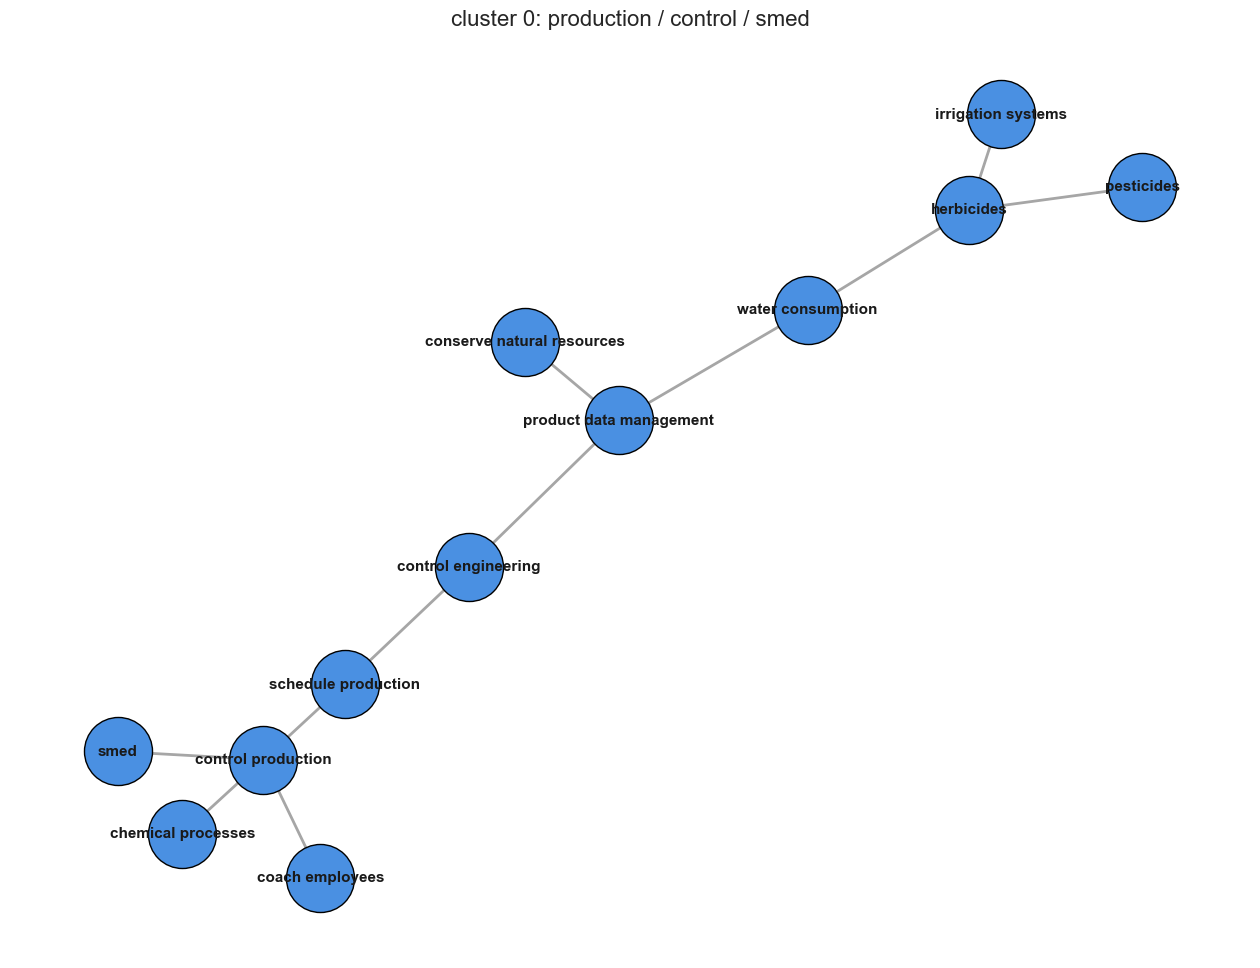

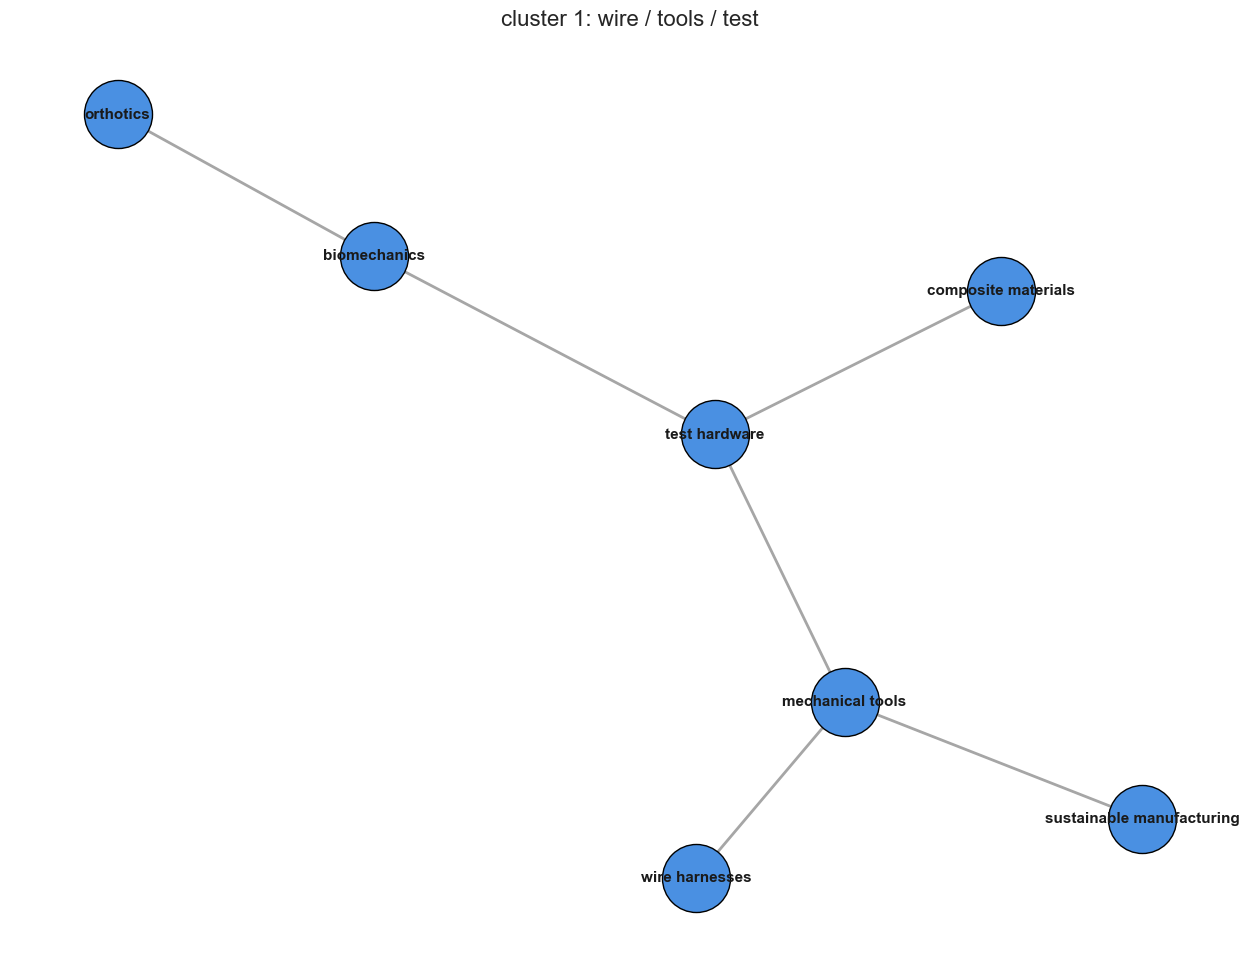

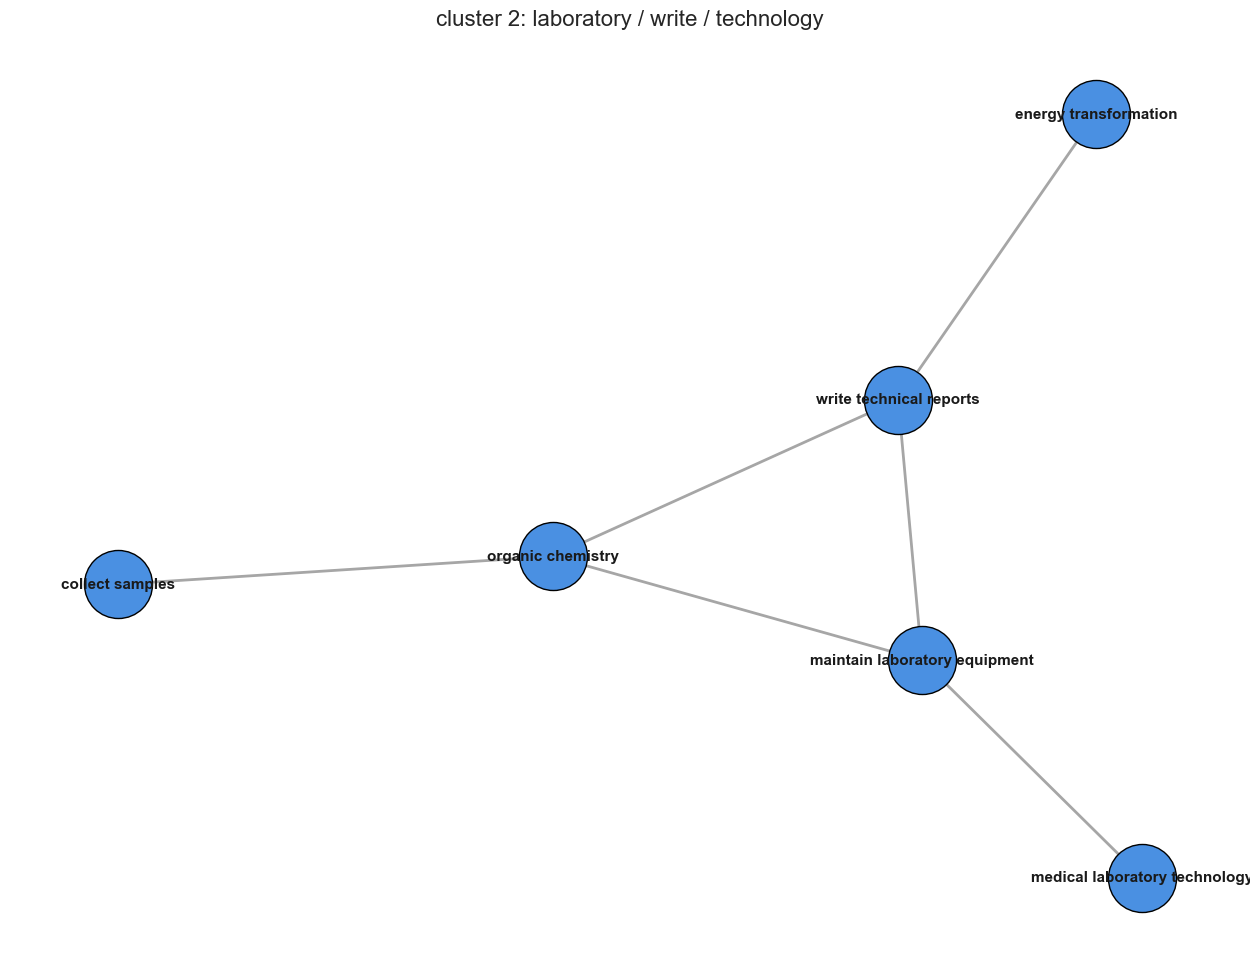

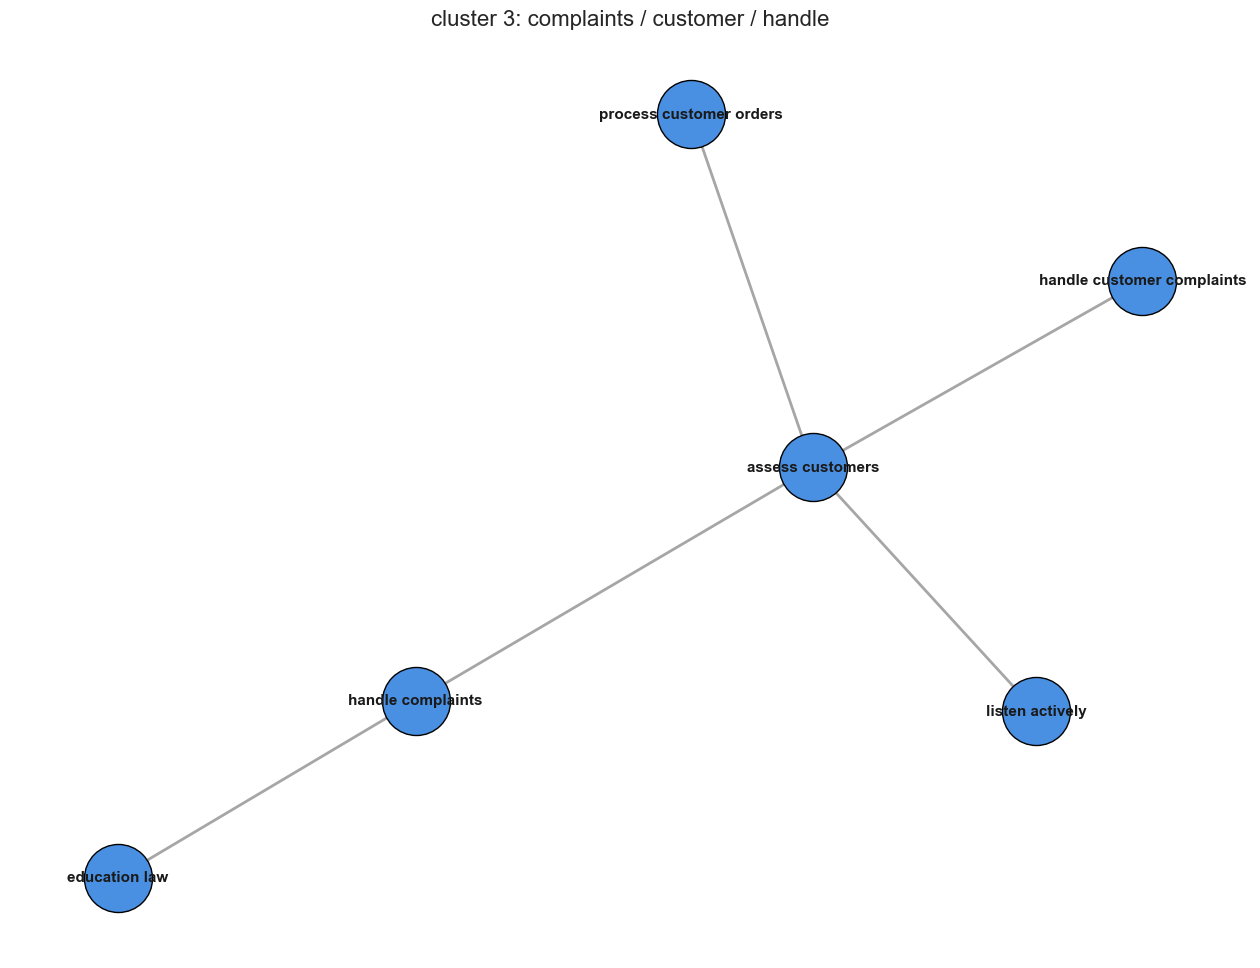

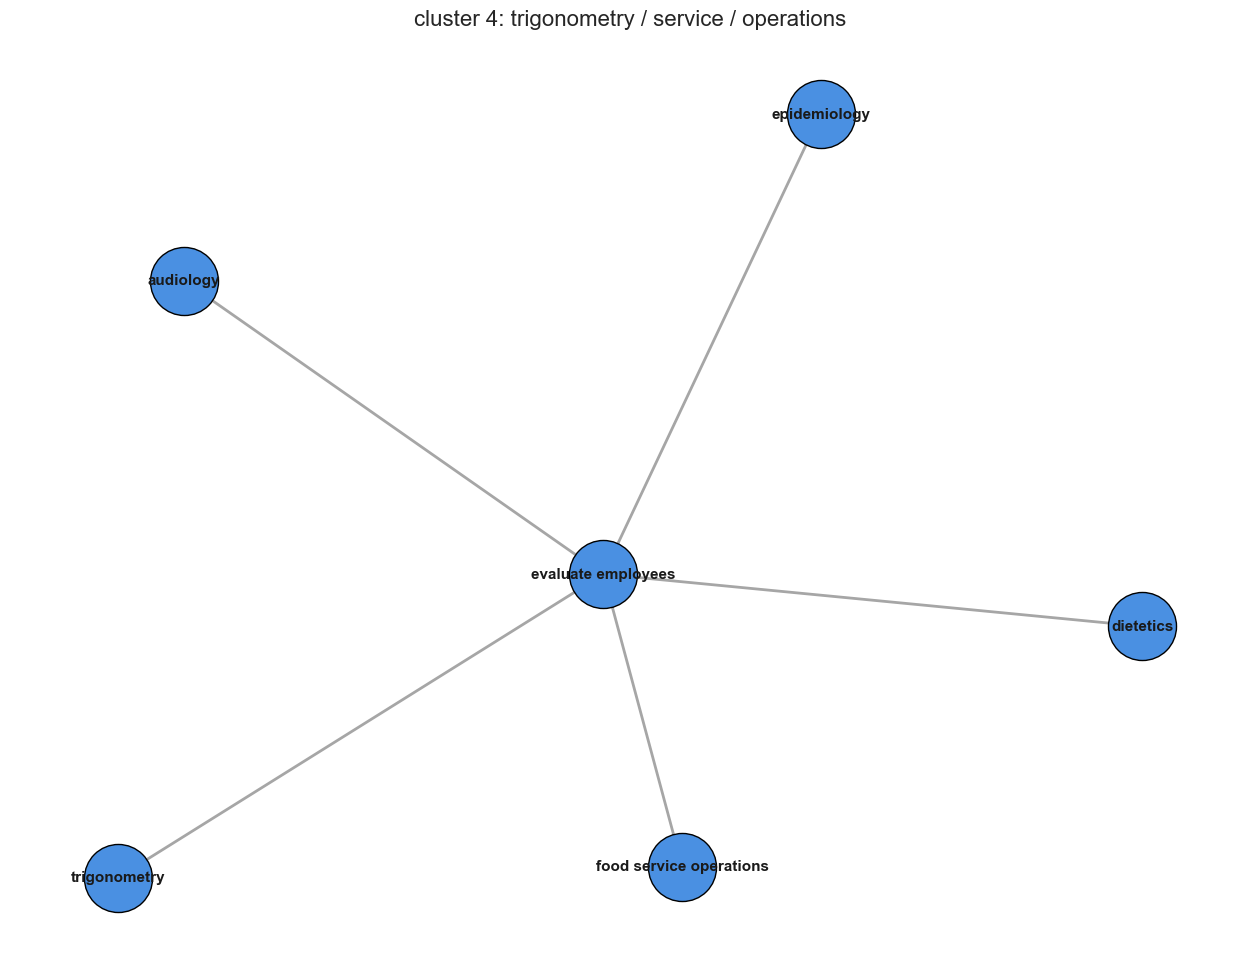

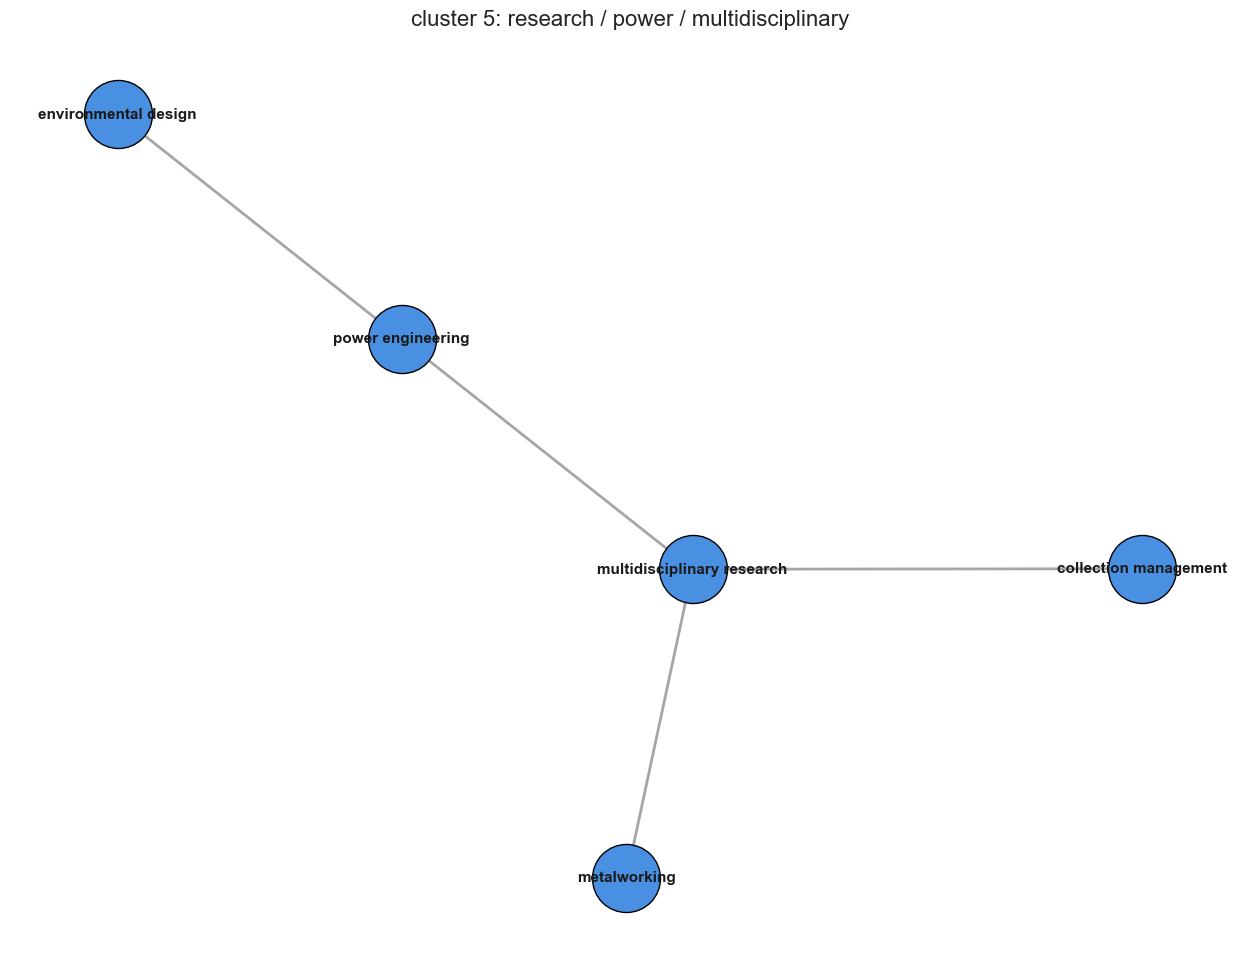

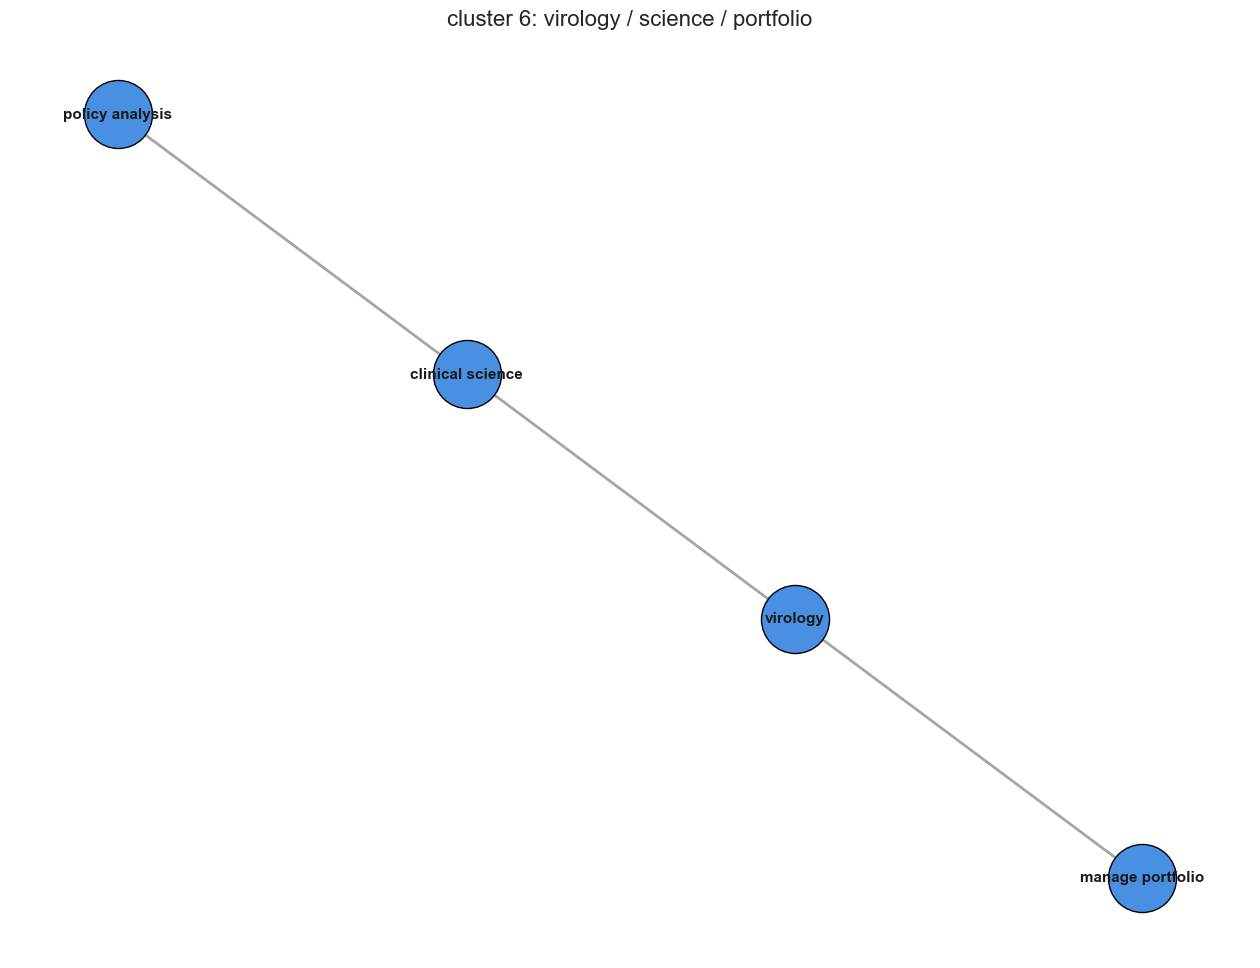

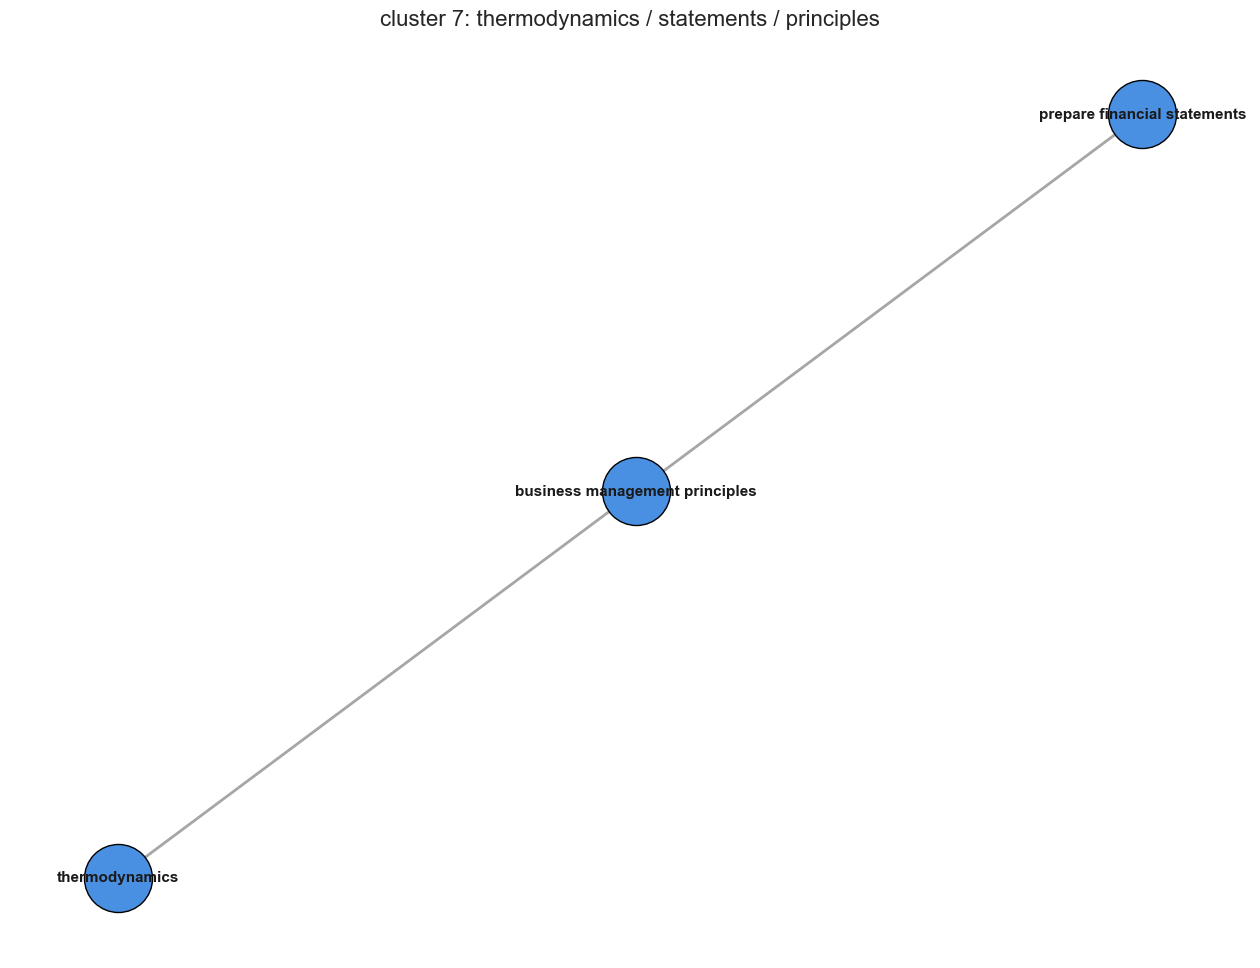

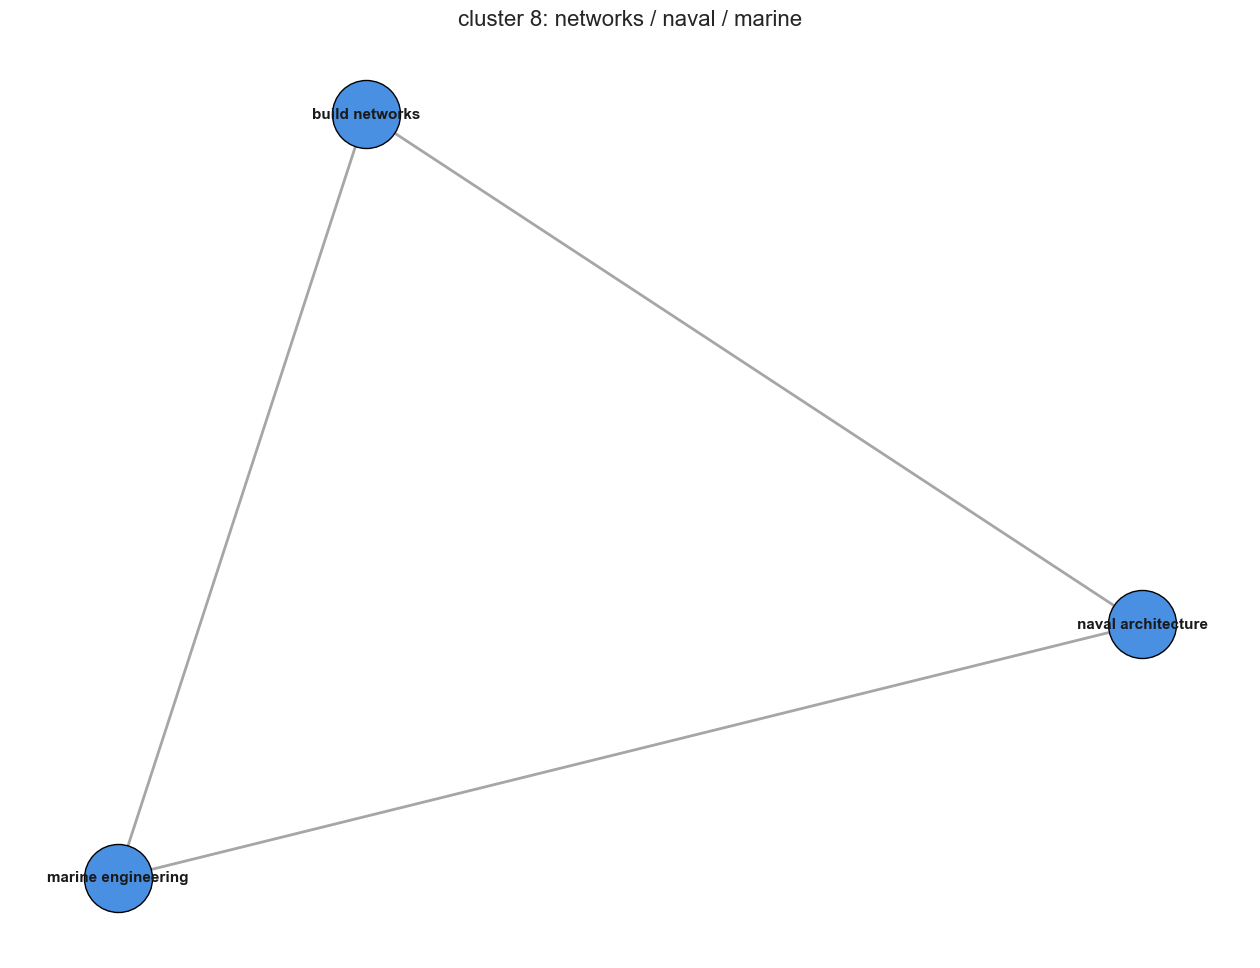

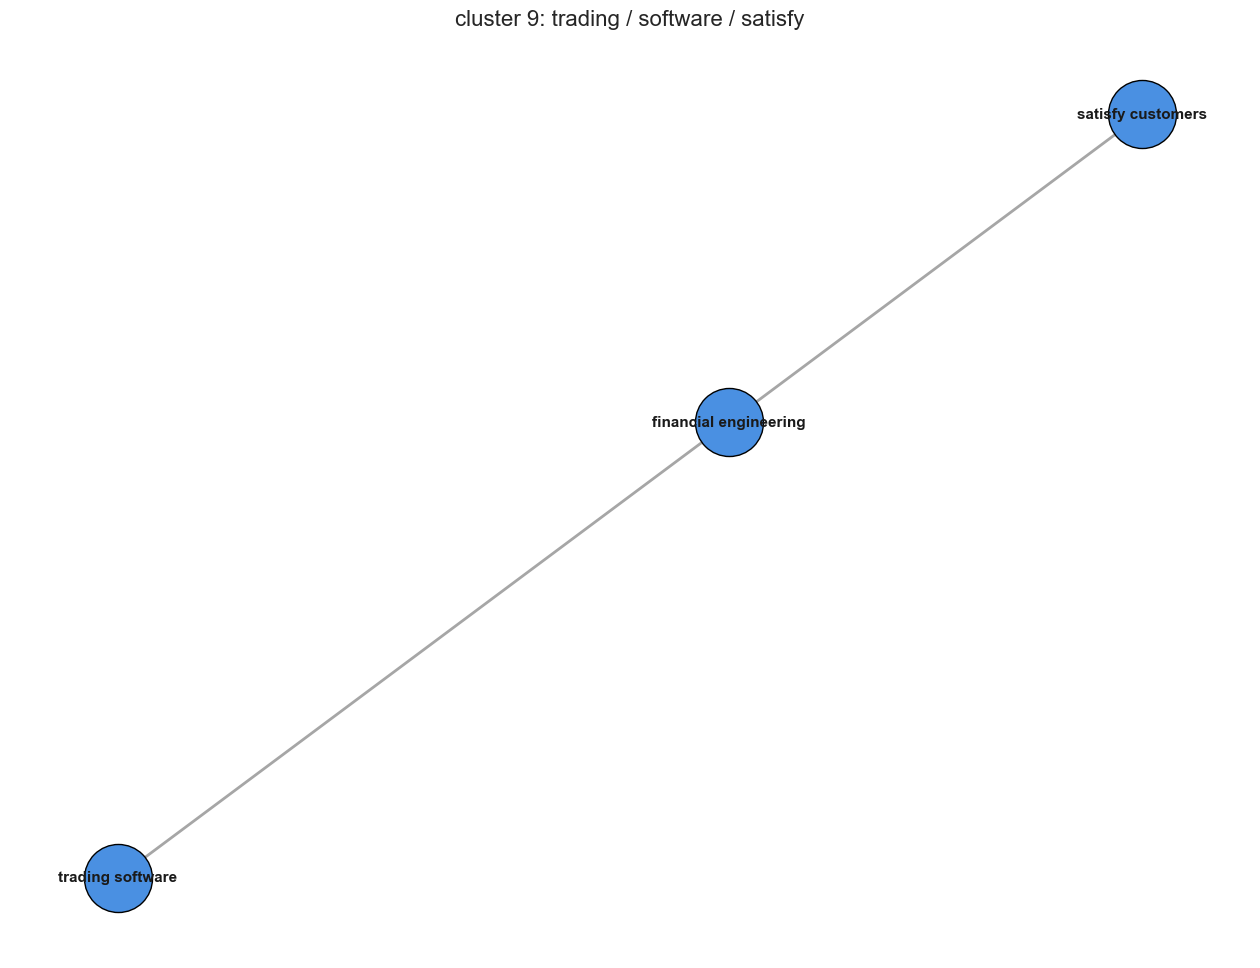

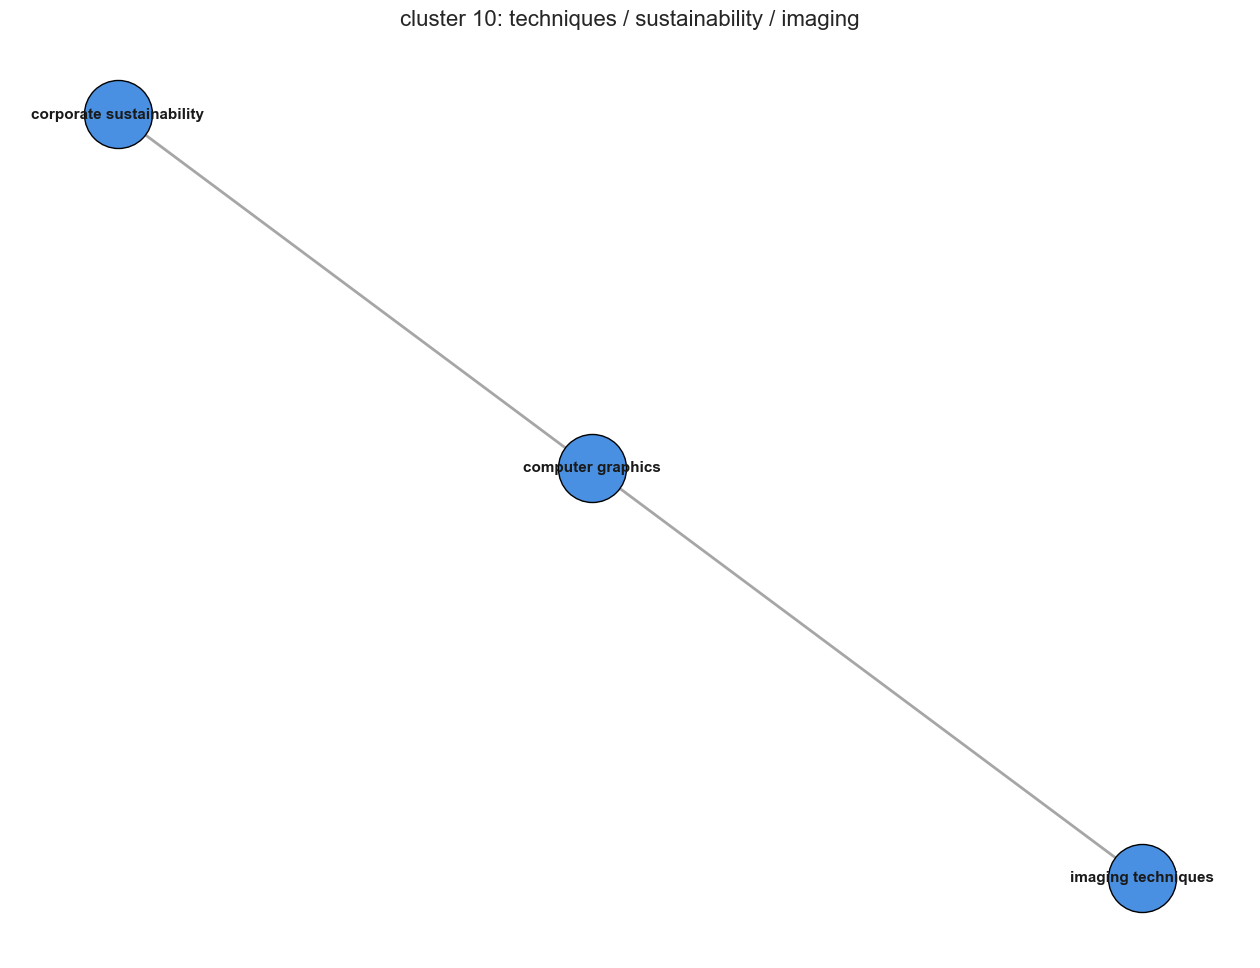

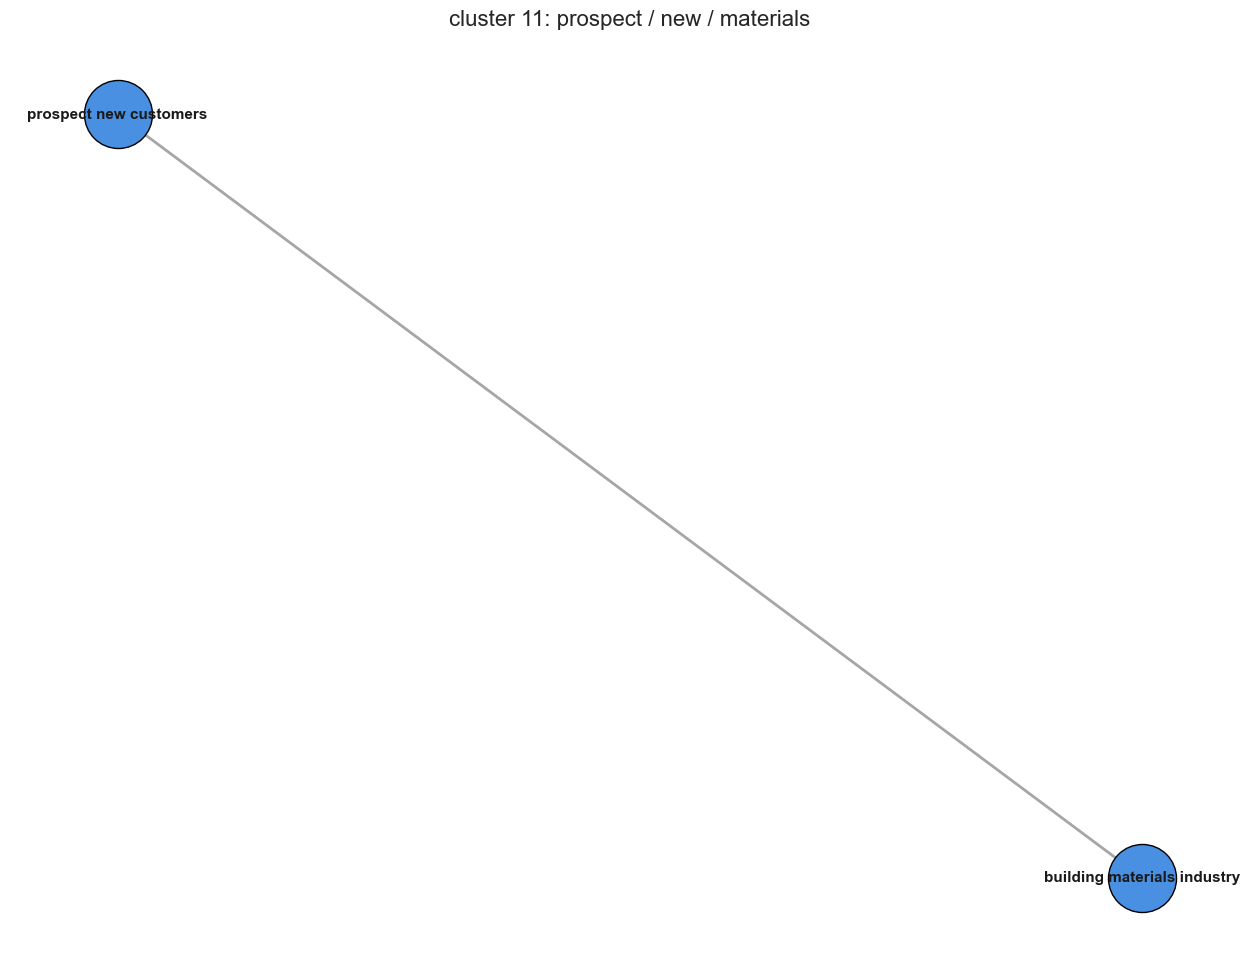

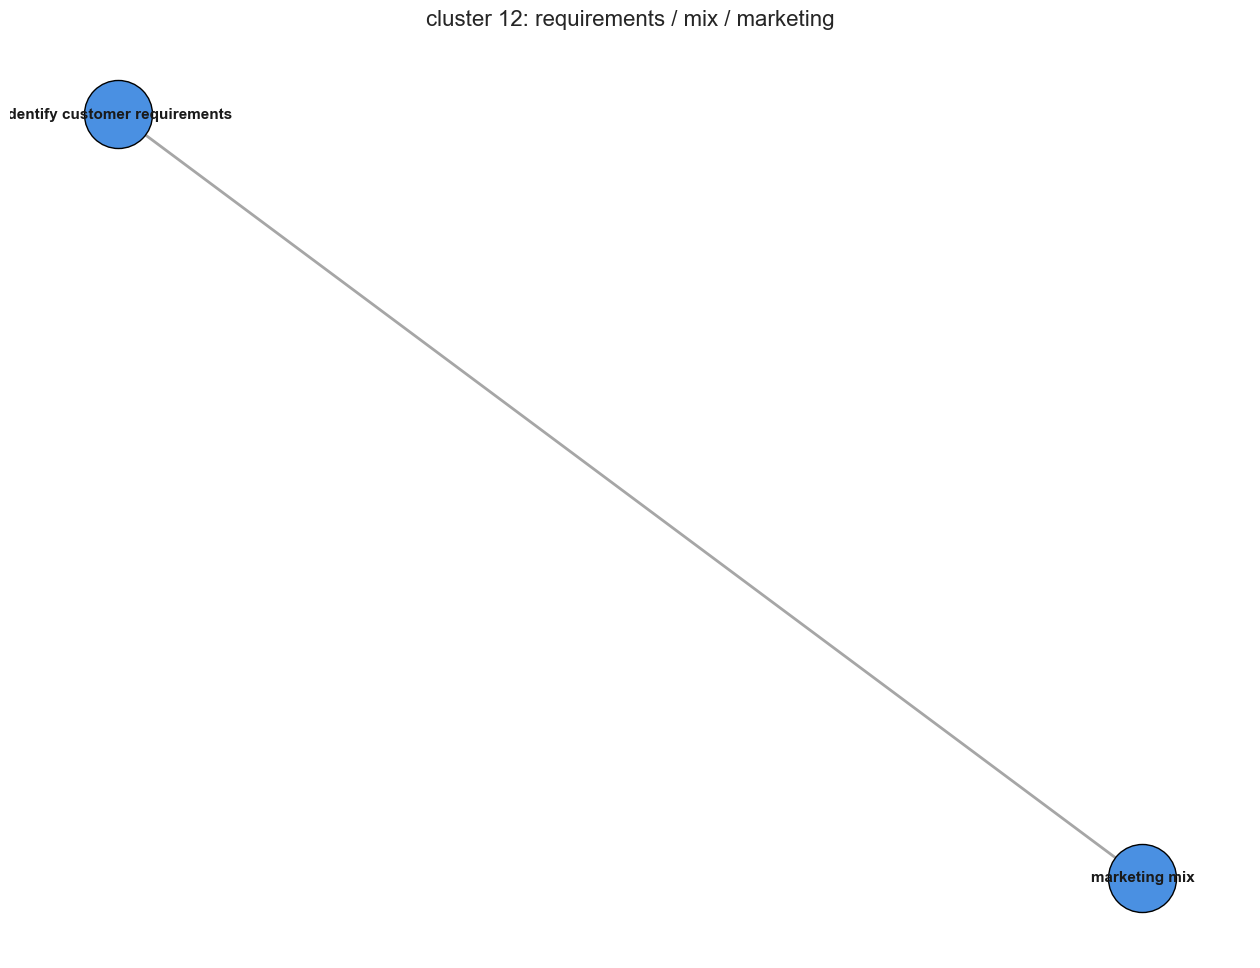

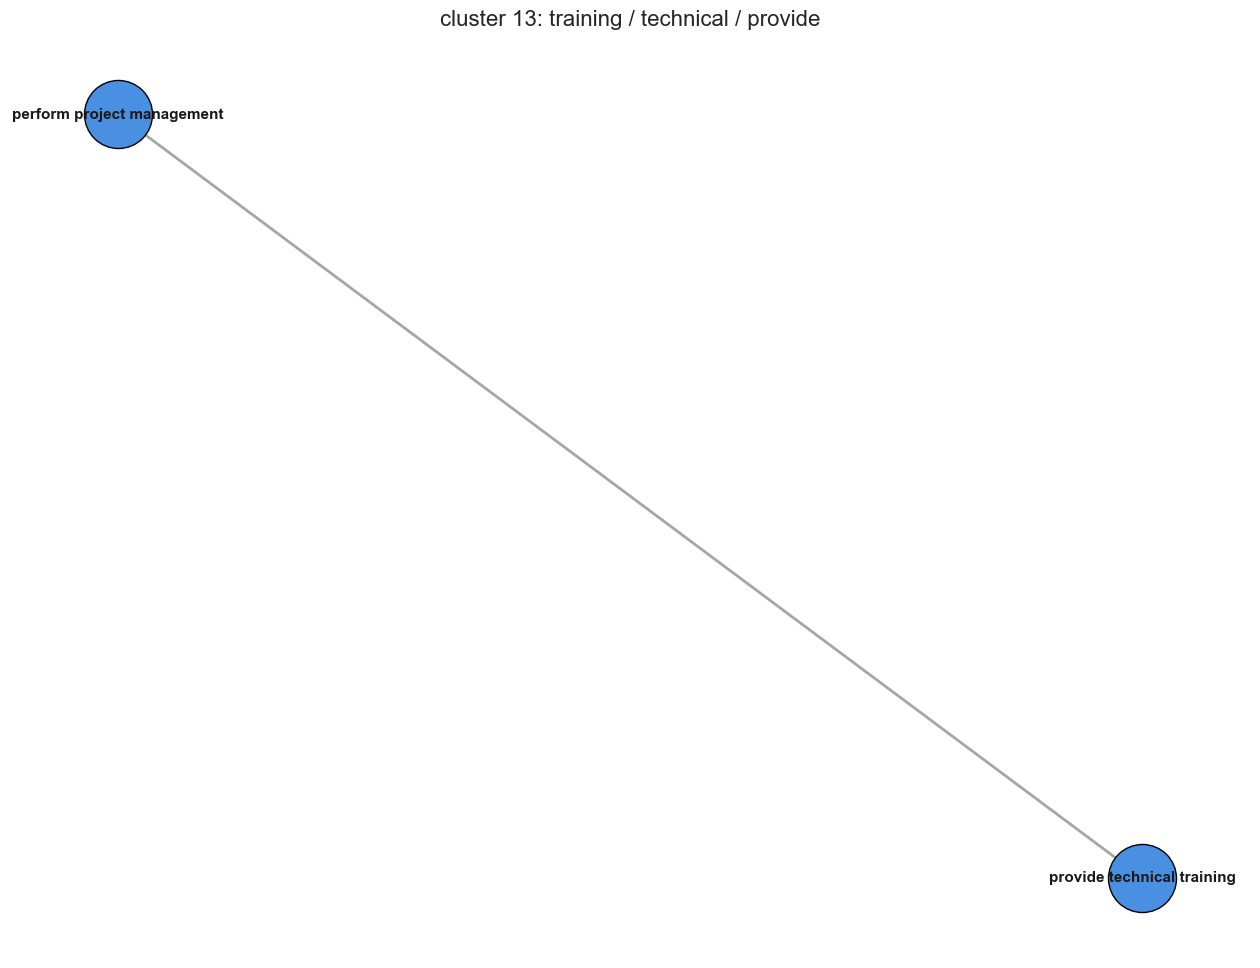

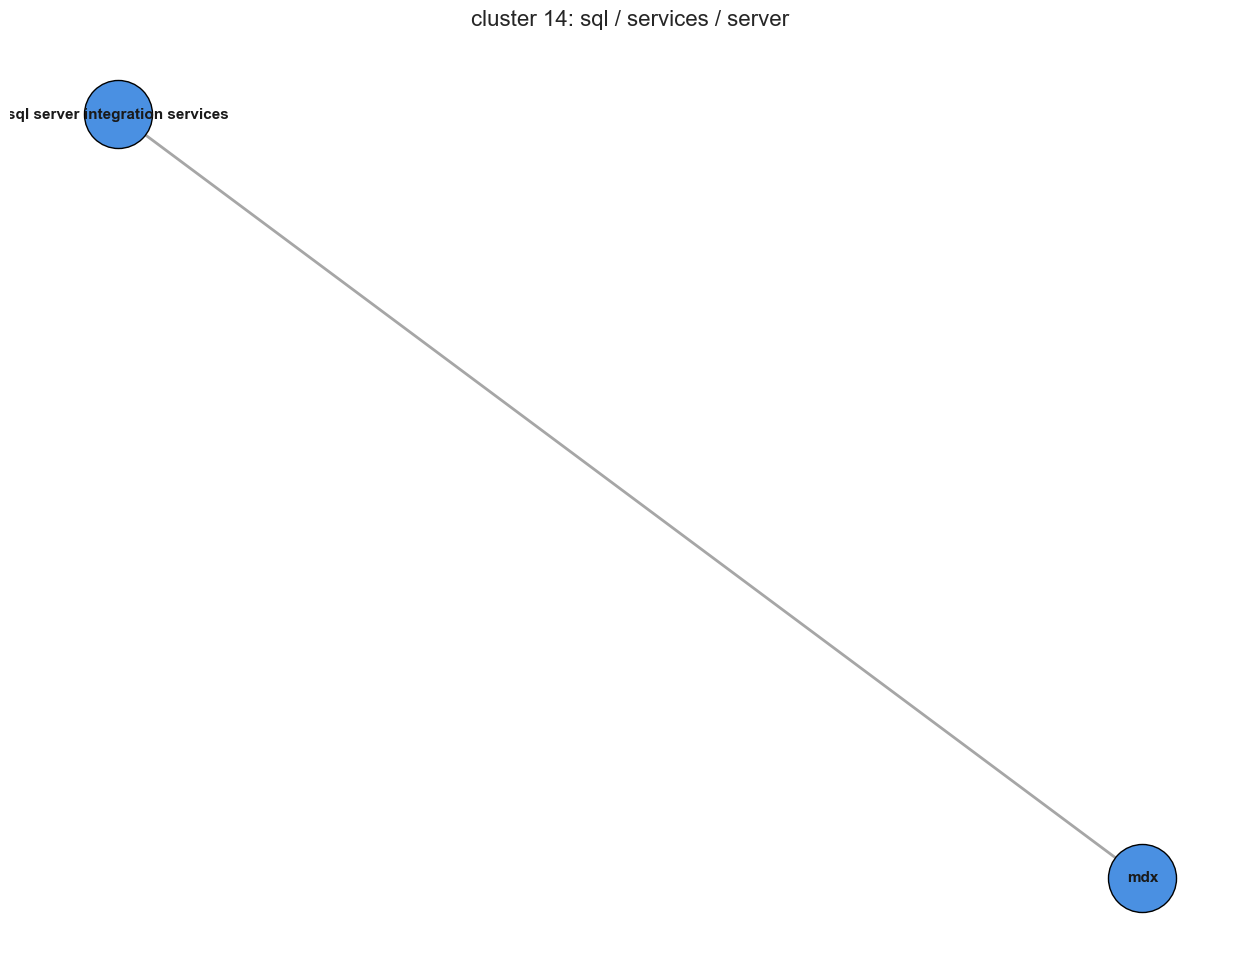

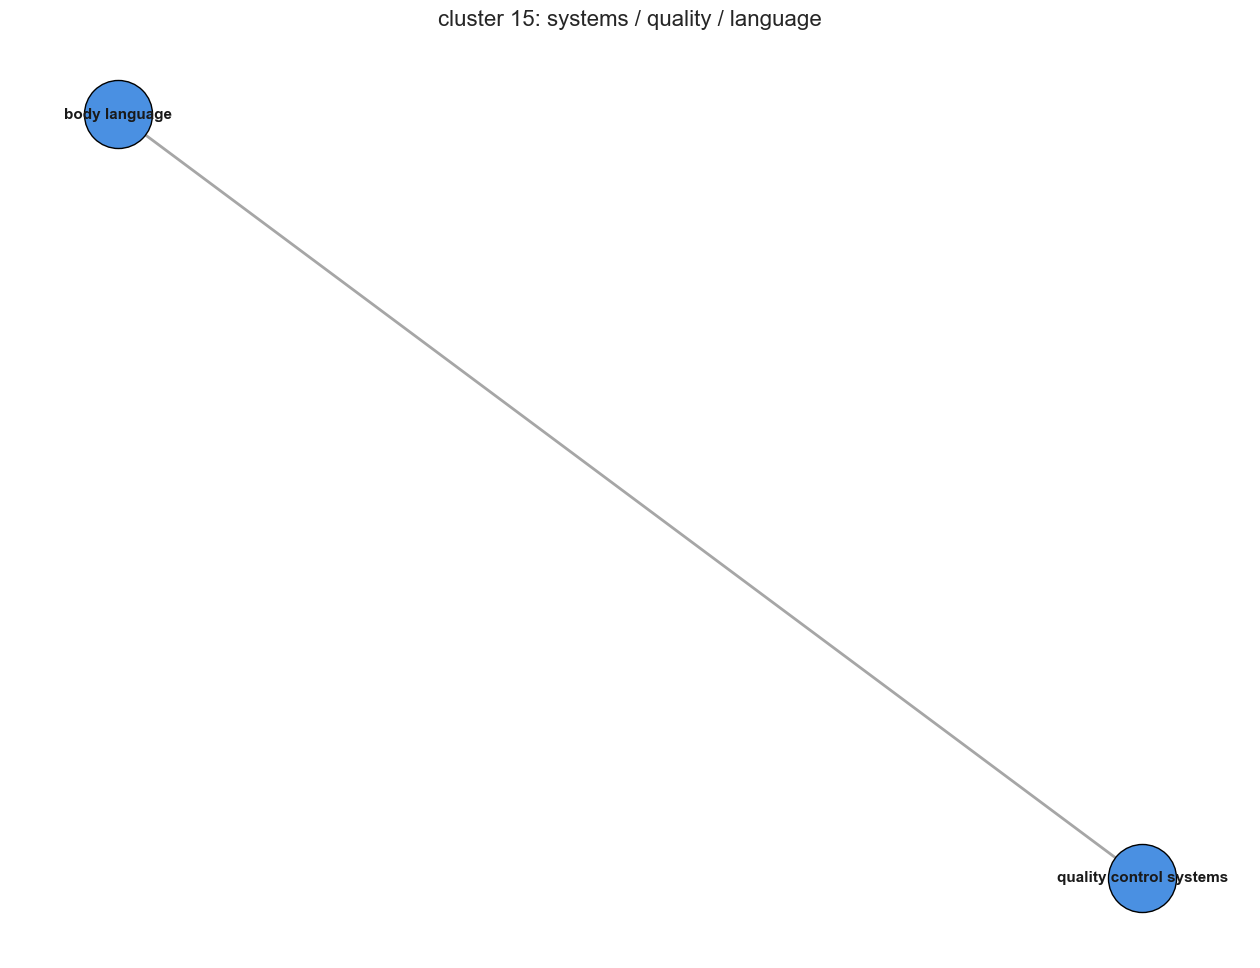

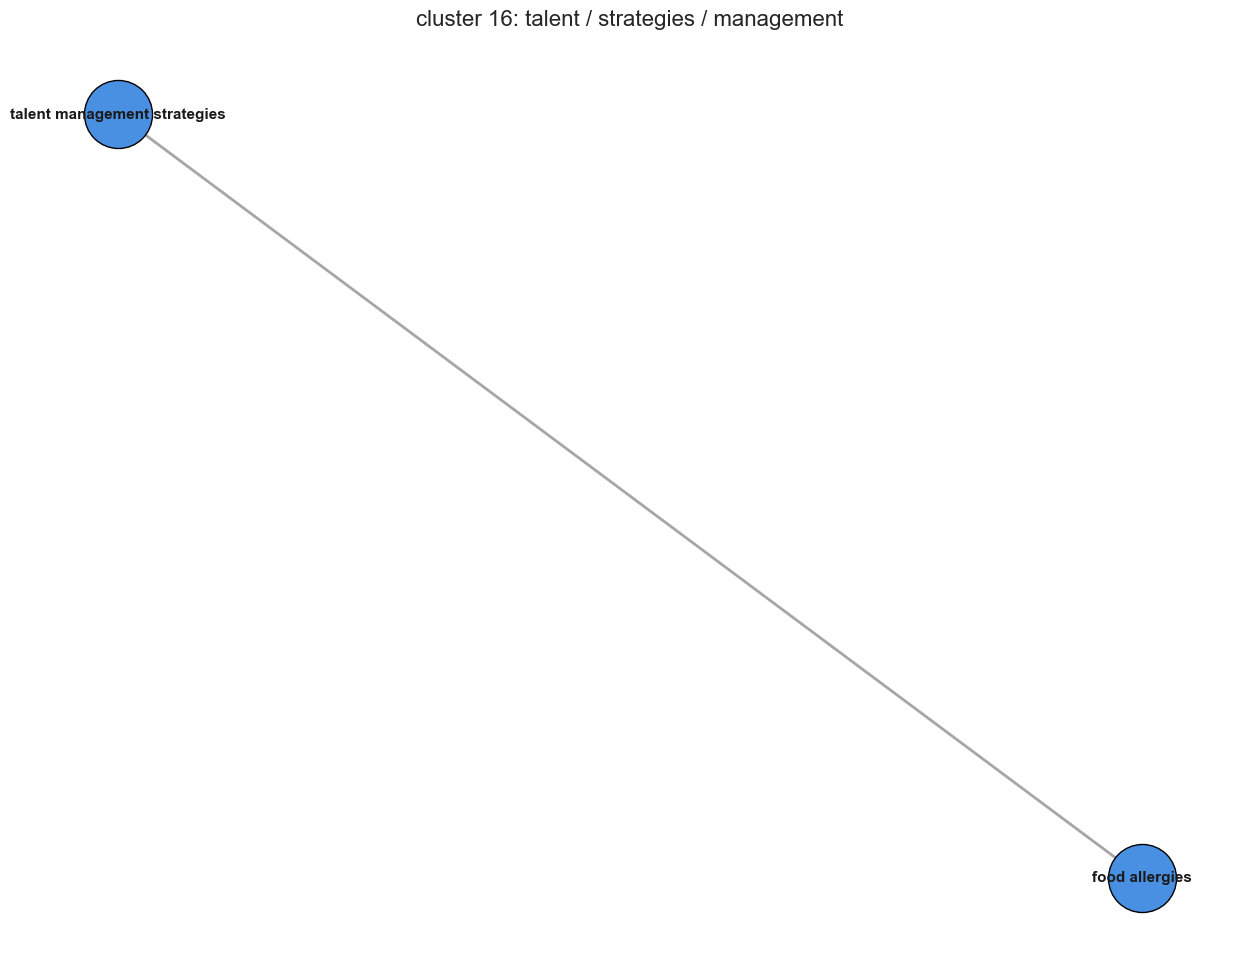

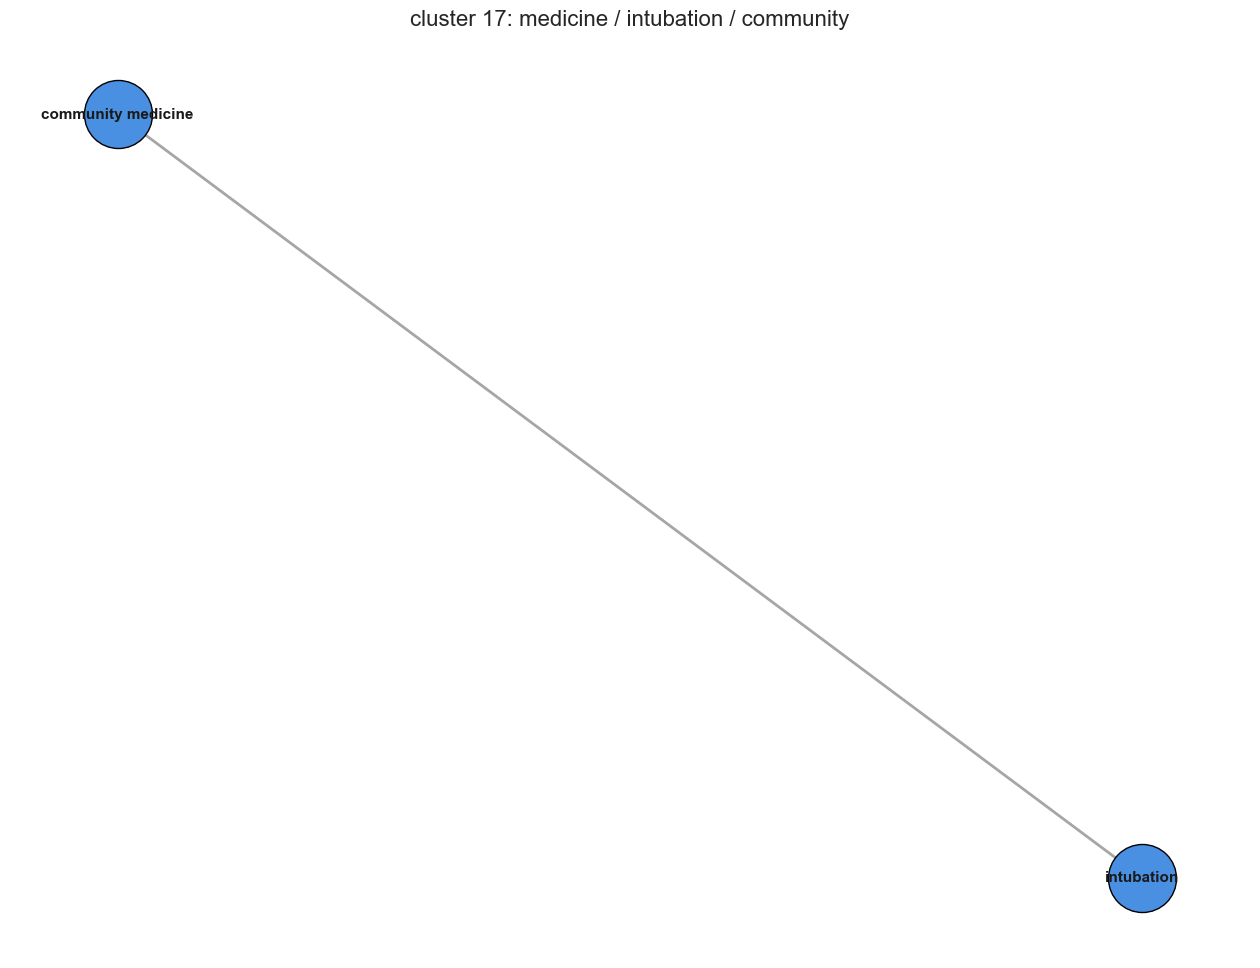

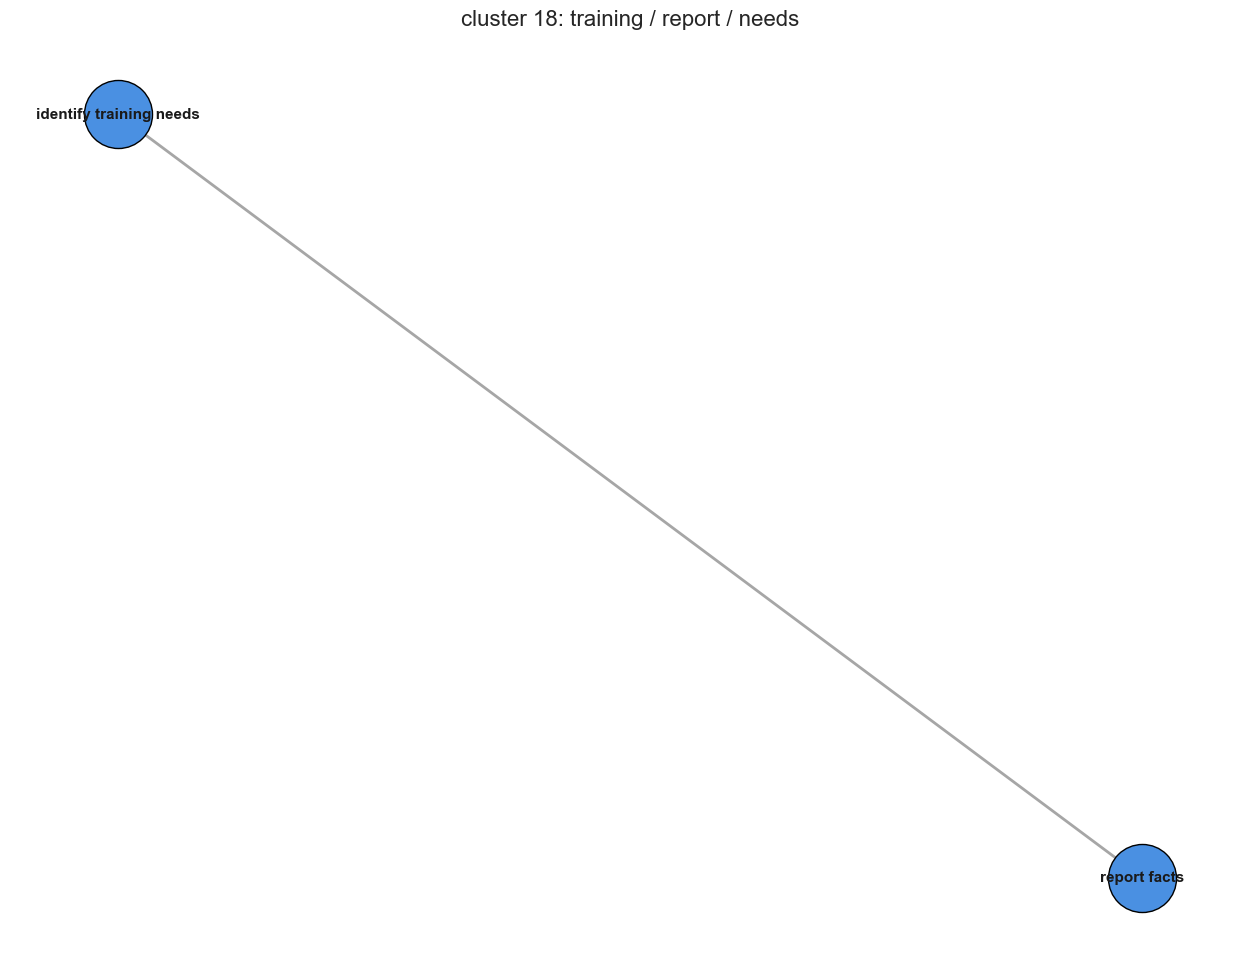

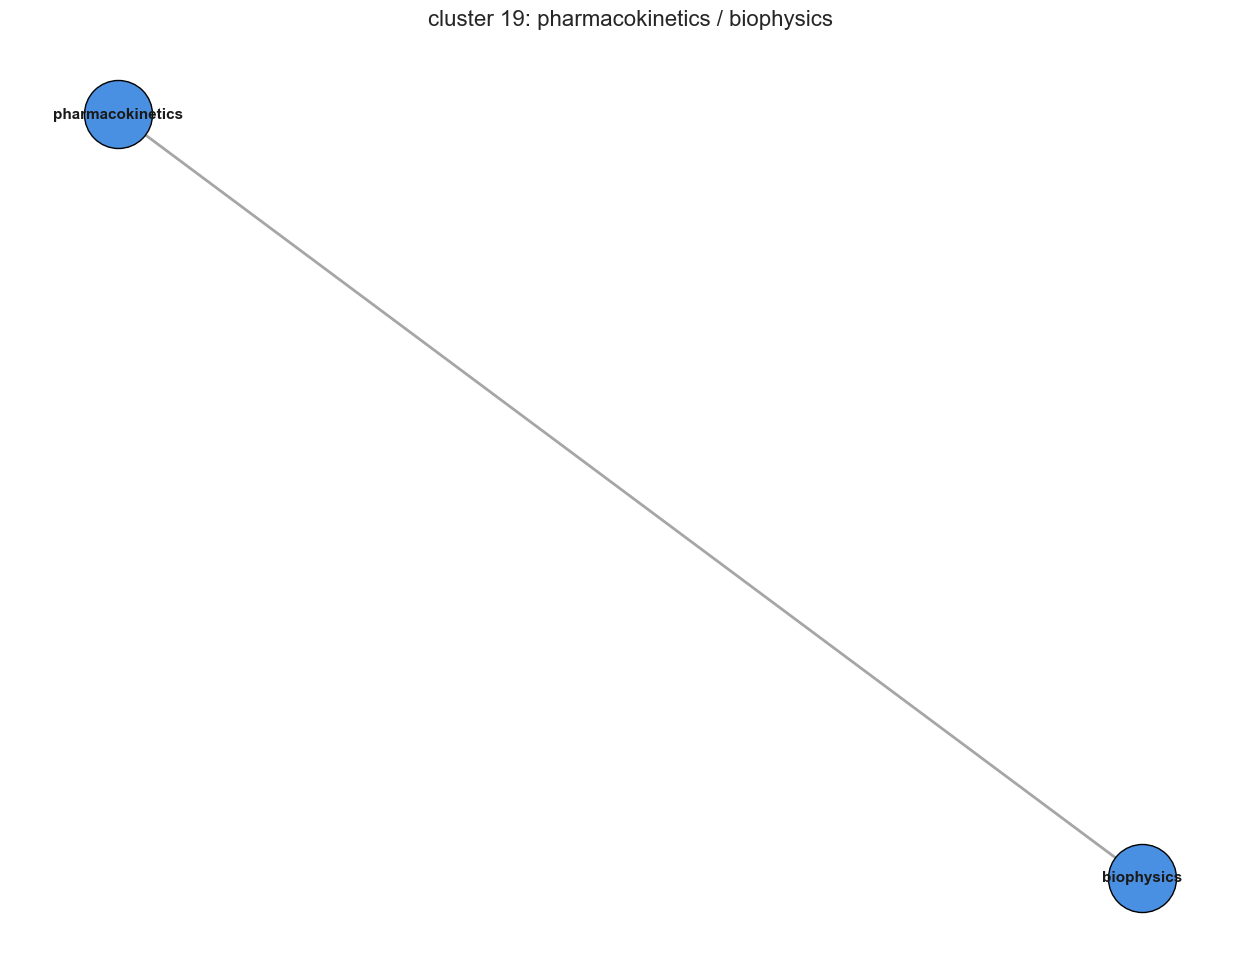

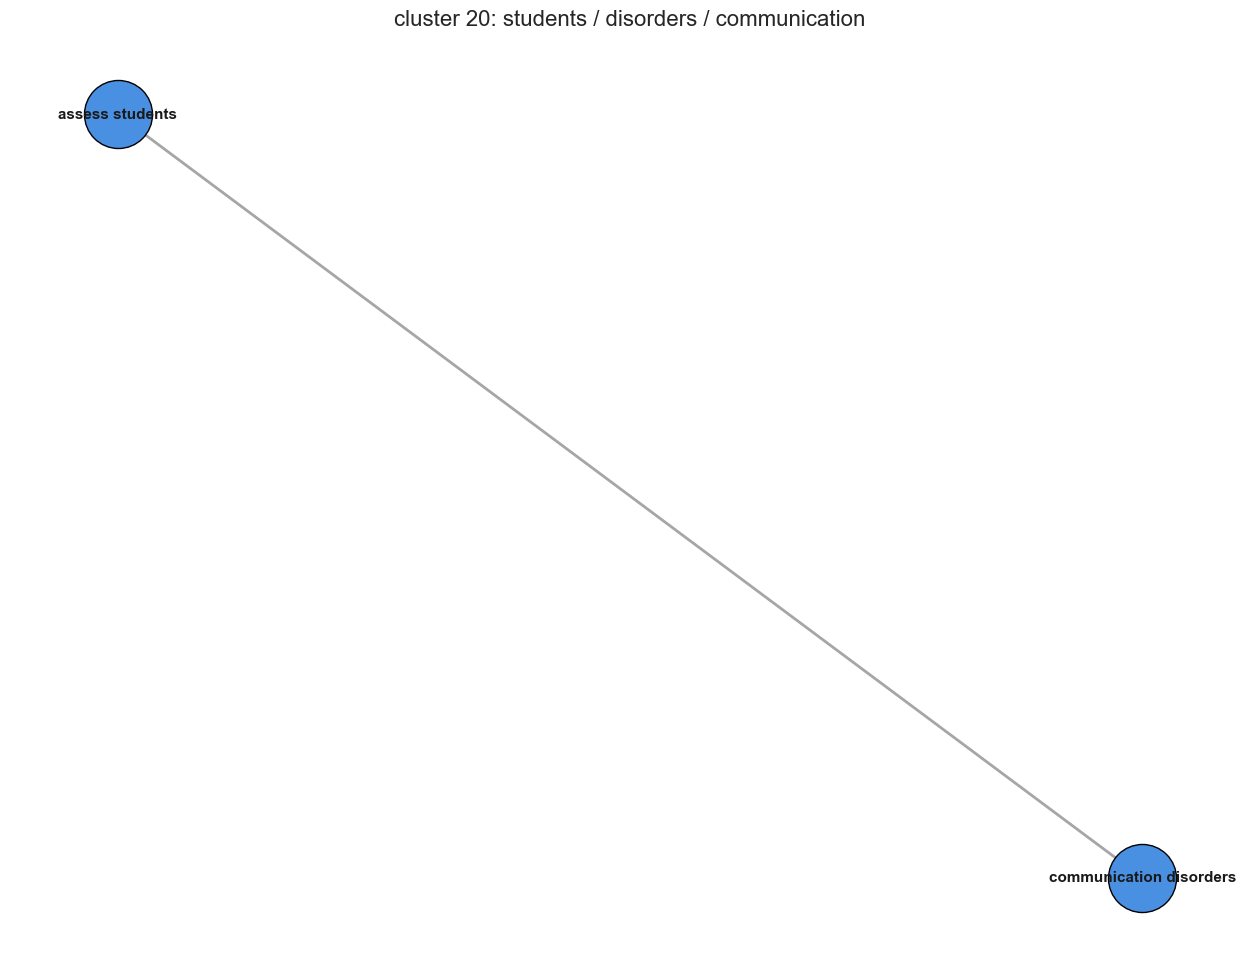

In [61]:
for cid, comm in enumerate(communities):
    plot_community(G, comm, cid)


# 5. RQ3 – Phân tích & dự đoán lương

## 5.1 Tiền xử lí

In [49]:
# RQ3 – Dự đoán lương với feature engineering

df = job_merged.copy()

# Giữ lại các job có thông tin med_salary hợp lệ
df = df[~df["med_salary"].isna()].copy()
df = df[df["med_salary"] > 0].copy()

print("Số job có med_salary:", len(df))


Số job có med_salary: 6266


In [50]:
# Loại bỏ outlier cực lớn (1% thấp nhất, 1% cao nhất)
q1, q99 = df["med_salary"].quantile([0.01, 0.99])
df = df[(df["med_salary"] >= q1) & (df["med_salary"] <= q99)].copy()

print("Sau khi loại outlier:", len(df))

# Log-transform salary (dự đoán trên thang log)
df["log_salary"] = np.log1p(df["med_salary"])


Sau khi loại outlier: 6147


In [51]:
# 1) Độ dài mô tả (nếu chưa có)
if "desc_len" not in df.columns:
    df["desc_len"] = df["description"].fillna("").astype(str).str.len()

# 2) Seniority từ title
df["seniority"] = (
    df["title"]
    .fillna("")
    .str.lower()
    .str.extract(r"(senior|junior|lead|manager|director)", expand=False)
)
df["seniority"] = df["seniority"].fillna("normal")


# 3) Số lượng kỹ năng từ ESCO (skills_list)
def count_list(x):
    if isinstance(x, list):
        return len(x)
    return 0


df["num_skills"] = df["skills_list"].apply(count_list)

# 4) Số lượng kỹ năng LinkedIn (linkedin_skills)
df["num_linkedin_skills"] = df["linkedin_skills"].apply(count_list)

# 5) Median salary trung bình theo country (context địa lý)
df["country_mean_salary"] = df.groupby("country")["med_salary"].transform("mean")

# 6) Tỉ lệ apply / view (đo mức hấp dẫn của job)
df["apply_rate"] = df["applies"] / (df["views"] + 1)

df.head()


,job_id,company_name,title,max_salary,pay_period,location,company_id,views,med_salary,min_salary,...,follower_count,linkedin_skills,desc_len,skills_list,log_salary,seniority,num_skills,num_linkedin_skills,country_mean_salary,apply_rate
9,2264355,Bay West Church,Worship Leader,NaN,MONTHLY,"Palm Bay, FL",28631247.0,5.0,350.00,NaN,...,3.0,"[Design, Art/Creative, Information Technology]",1447,[team building],5.860786,lead,1,3,18970.65602,NaN
16,95428182,CLEVELAND KIDS BOOK BANK,Administrative Coordinator,NaN,HOURLY,"Cleveland, OH",55624331.0,1.0,25.00,NaN,...,289.0,[Administrative],4666,"[accounting, communication, customer relations...",3.258097,normal,5,1,18970.65602,NaN
30,229924287,REquipment Durable Medical Equipment and Assis...,Administrative Assistant,NaN,HOURLY,"Woburn, MA",14773918.0,3.0,23.00,NaN,...,70.0,[Administrative],3702,"[accounting, communication, office administrat...",3.178054,normal,5,1,18970.65602,NaN
65,2147609712,The Job Network,Med-RN ER,NaN,HOURLY,"Murrieta, CA",167757.0,1.0,56.41,NaN,...,37938.0,[Health Care Provider],1271,[acute care],4.050219,normal,1,1,18970.65602,NaN
103,3040487795,Lead Lab,Digital Marketing Intern,NaN,HOURLY,"Redmond, WA",11444024.0,7.0,25.00,NaN,...,124.0,"[Marketing, Sales]",2279,[communication],3.258097,normal,1,2,18970.65602,0.375


## 5.2 Chọn features

In [52]:
# Numeric features
numeric_features = [
    "min_salary",
    "max_salary",
    "views",
    "applies",
    "employee_count",
    "follower_count",
    "desc_len",
    "num_skills",
    "num_linkedin_skills",
    "country_mean_salary",
    "apply_rate",
]

# Nếu remote_allowed là 0/1 thì cho vào numeric
if df["remote_allowed"].dtype != "O":
    numeric_features.append("remote_allowed")

# Categorical features
categorical_features = [
    "country",
    "state",
    "city",
    "formatted_experience_level",
    "formatted_work_type",
    "work_type",
    "pay_period",
    "currency",
    "company_size",
    "application_type",
    "seniority",
]

# Loại bỏ cột nào không tồn tại (phòng trường hợp dataset khác)
numeric_features = [c for c in numeric_features if c in df.columns]
categorical_features = [c for c in categorical_features if c in df.columns]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['min_salary', 'max_salary', 'views', 'applies', 'employee_count', 'follower_count', 'desc_len', 'num_skills', 'num_linkedin_skills', 'country_mean_salary', 'apply_rate', 'remote_allowed']
Categorical features: ['country', 'state', 'city', 'formatted_experience_level', 'formatted_work_type', 'work_type', 'pay_period', 'currency', 'company_size', 'application_type', 'seniority']


## 5.3 Chia tập train

In [53]:

target_col = "log_salary"

X = df[numeric_features + categorical_features].copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape


((4917, 23), (1230, 23))

## 5.4 Chạy mô hình

### 5.4.1 Preprocessing chung: numeric + categorical

In [54]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)


### 5.4.2 Định nghĩa các mô hình cần so sánh

In [55]:
# 2) 
models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=42
    ),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_depth=None,
        learning_rate=0.05,
        max_iter=300,
        random_state=42
    ),
}

### 5.4.3 Train + evaluate từng model

In [56]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

results = []
fitted_models = {}

for name, base_model in models.items():
    print(f"==== Training {name} ====")
    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", base_model)
    ])
    
    if name == "HistGradientBoosting":
        # Preprocess → dense
        Xt = pipe.named_steps["preprocess"].fit_transform(X_train)
        pipe.named_steps["model"].fit(Xt.toarray(), y_train)
        
        Xt_test = pipe.named_steps["preprocess"].transform(X_test)
        y_pred_log = pipe.named_steps["model"].predict(Xt_test.toarray())
    else:
        pipe.fit(X_train, y_train)
        y_pred_log = pipe.predict(X_test)
    
    fitted_models[name] = pipe
    
    # Chuyển về thang lương gốc
    y_true = np.expm1(y_test)
    y_pred = np.expm1(y_pred_log)
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    
    print(f"{name} -> RMSE={rmse:,.0f} | MAE={mae:,.0f} | R²={r2:.3f}\n")
    
    results.append({
        "model": name,
        "rmse": rmse,
        "mae": mae,
        "r2": r2
    })

results_df = pd.DataFrame(results).sort_values("rmse")
display(results_df)

==== Training LinearRegression ====


c:\Program Files\Python314\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['min_salary' 'max_salary']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Program Files\Python314\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['min_salary' 'max_salary']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Program Files\Python314\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['min_salary' 'max_salary']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


LinearRegression -> RMSE=17,798 | MAE=6,314 | R²=0.768

==== Training RandomForest ====


c:\Program Files\Python314\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['min_salary' 'max_salary']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Program Files\Python314\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['min_salary' 'max_salary']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


RandomForest -> RMSE=15,463 | MAE=5,202 | R²=0.825

==== Training GradientBoosting ====


c:\Program Files\Python314\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['min_salary' 'max_salary']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Program Files\Python314\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['min_salary' 'max_salary']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


GradientBoosting -> RMSE=16,561 | MAE=5,883 | R²=0.799

==== Training HistGradientBoosting ====
HistGradientBoosting -> RMSE=17,001 | MAE=5,892 | R²=0.788



c:\Program Files\Python314\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['min_salary' 'max_salary']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


,model,rmse,mae,r2
1,RandomForest,15463.211135,5201.939736,0.824846
2,GradientBoosting,16561.022404,5882.552762,0.799093
3,HistGradientBoosting,17001.218942,5892.477566,0.788271
0,LinearRegression,17798.412997,6313.954055,0.767950


### 5.4.4 Biểu đồ so sánh các mô hình

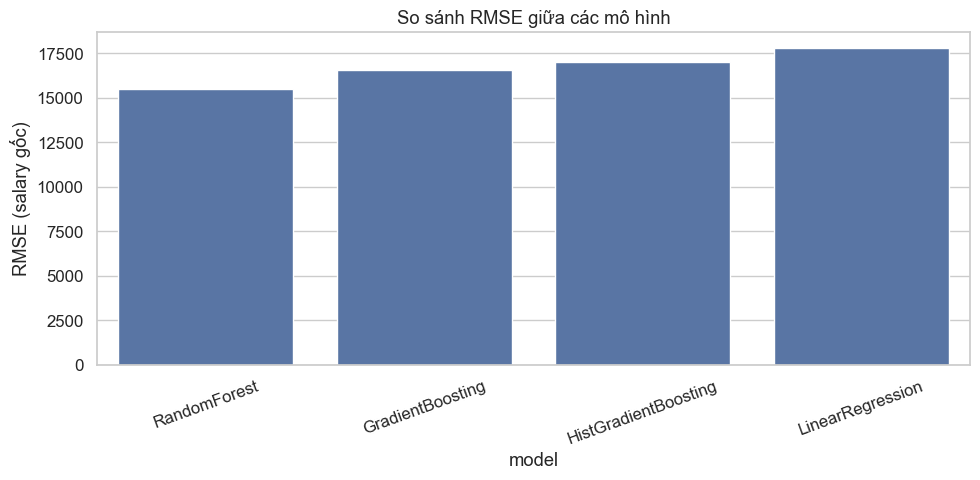

In [57]:
sns.barplot(data=results_df, x="model", y="rmse")
plt.ylabel("RMSE (salary gốc)")
plt.title("So sánh RMSE giữa các mô hình")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

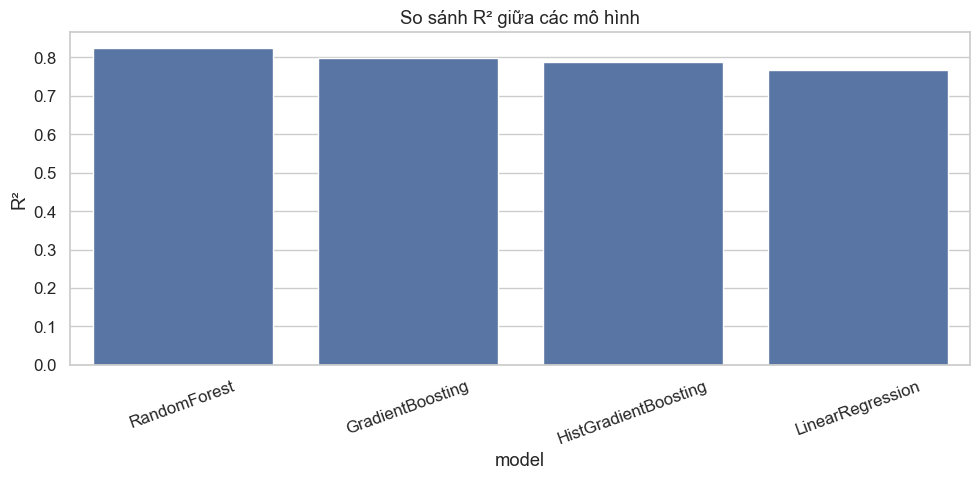

In [58]:
sns.barplot(data=results_df, x="model", y="r2")
plt.ylabel("R²")
plt.title("So sánh R² giữa các mô hình")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 5.4.5 Biểu đồ thực tế vs dự đoán cho mô hình tốt nhất

Mô hình tốt nhất theo RMSE: RandomForest


c:\Program Files\Python314\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['min_salary' 'max_salary']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


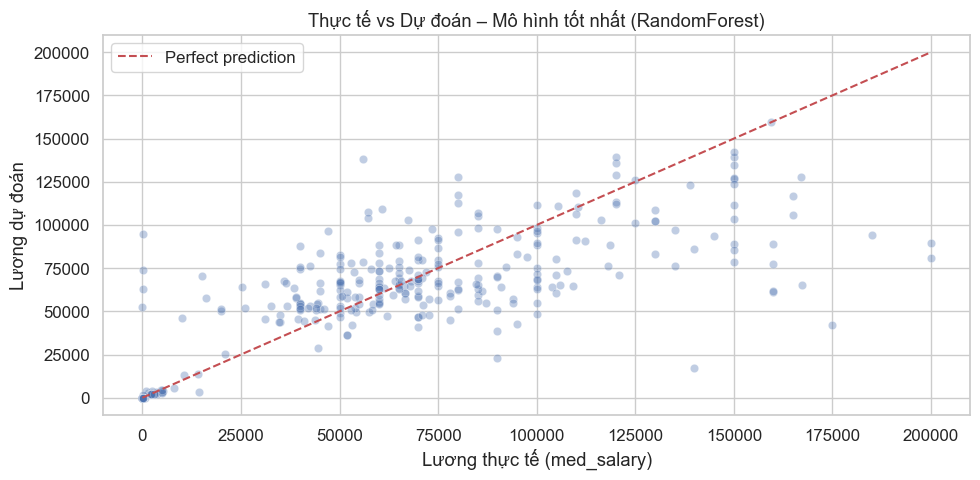

In [59]:
# Chọn model có RMSE thấp nhất
best_row = results_df.sort_values("rmse").iloc[0]
best_name = best_row["model"]
print("Mô hình tốt nhất theo RMSE:", best_name)

best_pipe = fitted_models[best_name]

# Dự đoán lại với mô hình tốt nhất
if best_name == "HistGradientBoosting":
    # preprocess -> dense như lúc train
    Xt_test = best_pipe.named_steps["preprocess"].transform(X_test)
    y_pred_log = best_pipe.named_steps["model"].predict(Xt_test.toarray())
else:
    y_pred_log = best_pipe.predict(X_test)

# Chuyển về thang lương gốc
y_true = np.expm1(y_test)
y_pred = np.expm1(y_pred_log)

# Nếu quá nhiều điểm, có thể lấy sample cho plot cho dễ nhìn
MAX_POINTS = 5000
if len(y_true) > MAX_POINTS:
    sample_idx = np.random.choice(len(y_true), size=MAX_POINTS, replace=False)
    y_true_plot = y_true.iloc[sample_idx]
    y_pred_plot = pd.Series(y_pred, index=y_true.index).iloc[sample_idx]
else:
    y_true_plot = y_true
    y_pred_plot = y_pred

sns.scatterplot(x=y_true_plot, y=y_pred_plot, alpha=0.35)

# Đường chéo y = x
max_val = max(y_true_plot.max(), y_pred_plot.max())
plt.plot([0, max_val], [0, max_val], "r--", linewidth=1.5, label="Perfect prediction")

plt.xlabel("Lương thực tế (med_salary)")
plt.ylabel("Lương dự đoán")
plt.title(f"Thực tế vs Dự đoán – Mô hình tốt nhất ({best_name})")
plt.legend()
plt.tight_layout()
plt.show()


### 5.4.6 Features important

In [63]:
# model là Pipeline bạn đã fit: steps=[("preprocess", preprocess), ("model", rf)]
preprocess_fitted = best_pipe.named_steps["preprocess"]
rf_fitted = best_pipe.named_steps["model"]

# Lấy tên feature sau khi preprocess (numeric + onehot)
feature_names = preprocess_fitted.get_feature_names_out()

# Lấy importance từ RandomForest
importances = rf_fitted.feature_importances_

fi = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

In [66]:
def group_feature_name(feat: str) -> str:
    # feat thường dạng: "num__views" hoặc "cat__country_US"
    if feat.startswith("num__"):
        return feat.replace("num__", "")
    if feat.startswith("cat__"):
        # lấy tên cột trước dấu "_" đầu tiên
        s = feat.replace("cat__", "")
        return s.split("_")[0]
    return feat

fi["feature"] = fi["feature"].apply(group_feature_name)
fi_group = fi.groupby("feature", as_index=False)["importance"].sum().sort_values("importance", ascending=False)

display(fi_group.head(30))


,feature,importance
14,pay,0.970723
3,city,0.004139
11,formatted,0.003889
10,follower_count,0.003406
8,desc_len,0.003338
17,state,0.002405
4,company,0.002149
9,employee_count,0.002124
19,work,0.001798
13,num_skills,0.001373


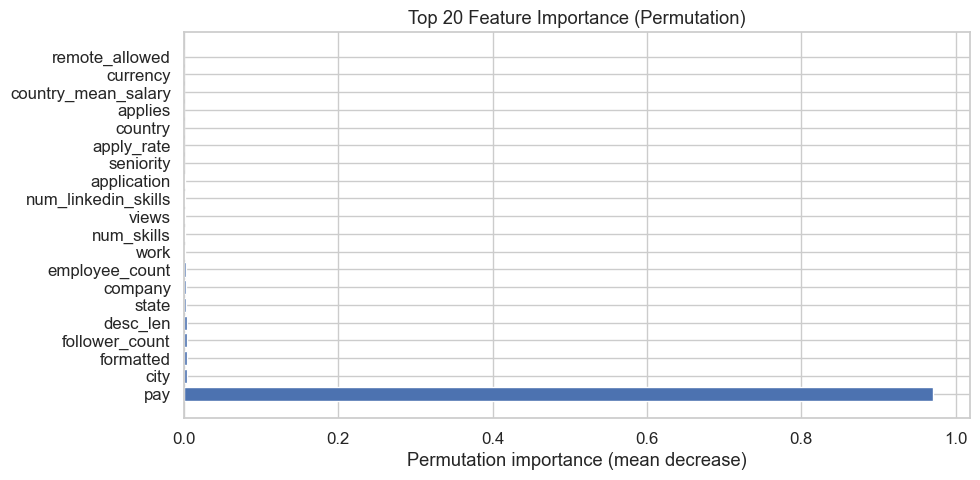

In [69]:
plt.barh(fi_group["feature"], fi_group["importance"])
plt.xlabel("Permutation importance (mean decrease)")
plt.title("Top 20 Feature Importance (Permutation)")
plt.tight_layout()
plt.show()

# 6. Kết luận

## 6.1 **KẾT LUẬN RQ1 – Phân cụm nhóm nghề nghiệp từ mô tả công việc**

Việc áp dụng TF-IDF kết hợp với K-Means đã tạo ra 15 cụm nghề nghiệp rõ ràng từ hơn 20.000 mô tả công việc. Phân tích từ khóa đặc trưng cho thấy các cụm thu được phản ánh các nhóm nghề nghiệp thực tế như: Công nghệ thông tin, Sản xuất – Kỹ thuật, Y tế – Điều dưỡng, Kế toán – Tài chính, Marketing, Bán hàng – Retail, Dịch vụ khách hàng, Công trình – Quản lý dự án,…

Khi đối chiếu với danh mục kỹ năng LinkedIn (LinkedIn Skill Mapping), các cụm RQ1 thể hiện sự tương đồng rất mạnh. Ví dụ:

* Cluster 14 (software, cloud, development) gần như trùng khớp với nhóm **Information Technology**.
* Cluster 9 và 11 (nurse, patient care, healthcare) tương ứng với **Health Care Provider**.
* Cluster 2 (accounting, financial reporting) khớp với **Accounting/Auditing** và **Finance**.
* Cluster 12 (store, retail, customer service) phù hợp với **Sales/Retail**.
* Cluster 10 (marketing, social media, brand) phù hợp với **Marketing**.

Heatmap cho thấy các job thuộc từng LinkedIn Skill Category tập trung mạnh vào đúng cụm RQ1 tương ứng, chứng tỏ mô tả công việc chứa tín hiệu nghề nghiệp rõ ràng và mô hình phân cụm đã khai thác hiệu quả cấu trúc ngữ nghĩa của dữ liệu.

**Kết luận:**

> RQ1 đã thành công trong việc xây dựng các nhóm nghề nghiệp tự động từ dữ liệu mô tả công việc. Các cụm thu được có tính gắn kết cao, phản ánh đúng cấu trúc thị trường lao động và tương thích mạnh mẽ với phân loại kỹ năng LinkedIn. Điều này khẳng định tính hợp lệ của phương pháp phân cụm và cung cấp nền tảng quan trọng cho các phân tích kỹ năng (RQ2) và dự đoán lương (RQ3).


## 6.2 **KẾT LUẬN RQ2 – Khai phá các nhóm kỹ năng (Skill Bundles) từ ESCO**

Thông qua việc kết hợp **ESCO skills ontology** với phân tích **n-gram xuất hiện thực tế trong mô tả công việc**, nghiên cứu đã xây dựng được **ma trận xuất hiện kỹ năng (document–skill matrix)** và khai phá thành công các **cặp kỹ năng có mức độ đồng xuất hiện cao** dựa trên chỉ số *lift*. Trên cơ sở đó, **network graph** cùng phương pháp **community detection (greedy modularity)** đã được sử dụng để xác định **21 nhóm kỹ năng đặc trưng (skill bundles)** trong dữ liệu tuyển dụng.

Một số nhóm kỹ năng tiêu biểu được phát hiện bao gồm:

* **Sản xuất – Kiểm soát – Tối ưu quy trình:**
  *smed, control production, control engineering, chemical processes, water consumption, irrigation systems*

* **Cơ khí – Chế tạo – Vật liệu:**
  *mechanical tools, composite materials, wire harnesses, orthotics, sustainable manufacturing*

* **Khoa học – Phòng thí nghiệm – Hóa học:**
  *organic chemistry, collect samples, medical laboratory technology, maintain laboratory equipment*

* **Y tế – Chăm sóc sức khỏe:**
  *clinical science, virology, epidemiology, community medicine, intubation*

* **Dịch vụ khách hàng – Vận hành:**
  *handle customer complaints, assess customers, listen actively, process customer orders*

* **Tài chính – Quản trị – Kinh doanh:**
  *prepare financial statements, business management principles, financial engineering, trading software*

* **Marketing – Nghiên cứu thị trường:**
  *marketing mix, identify customer requirements, prospect new customers*

Các nhóm kỹ năng này cho thấy **sự liên kết mạnh mẽ giữa các kỹ năng thường được yêu cầu đồng thời trong cùng một vị trí công việc**, phản ánh **nhu cầu thực tế của thị trường lao động** thay vì chỉ dựa trên cấu trúc phân loại lý thuyết của ESCO. Việc **gán nhãn tự động cho từng cộng đồng bằng TF-IDF** giúp làm rõ bản chất chức năng của từng *skill bundle* và hỗ trợ diễn giải kết quả một cách trực quan.

**Kết luận**

> **RQ2 đã khai phá thành công cấu trúc kỹ năng ẩn trong dữ liệu tuyển dụng thông qua ESCO ontology.**
> Các *skill bundles* thu được phản ánh chính xác các bộ kỹ năng đặc trưng theo từng lĩnh vực nghề nghiệp, từ sản xuất, kỹ thuật, y tế đến kinh doanh và dịch vụ. Kết quả này không chỉ giúp hiểu sâu hơn về nhu cầu kỹ năng theo ngành mà còn có tiềm năng ứng dụng trong **thiết kế chương trình đào tạo**, **tư vấn nghề nghiệp**, và **đề xuất lộ trình học kỹ năng** phù hợp cho người lao động.


## 6.3 **KẾT LUẬN RQ3 – Phân tích và dự đoán mức lương**

Sau khi làm sạch dữ liệu lương, loại bỏ outlier và áp dụng log-transform, nhiều mô hình dự đoán đã được thử nghiệm: Linear Regression, Random Forest, Gradient Boosting và HistGradientBoosting. Kết quả cho thấy **Random Forest** đạt hiệu suất tốt nhất với RMSE thấp và R² cao so với các mô hình còn lại.

Biểu đồ thực tế vs dự đoán cho thấy mô hình nắm bắt tốt xu hướng của dữ liệu, mặc dù vẫn tồn tại sai số ở các job có mức lương rất cao — điều hoàn toàn bình thường với dữ liệu lương nhiễu và phân phối lệch.

Phân tích độ quan trọng của thuộc tính (feature importance) chỉ ra rằng:

* **Min_salary** và **max_salary** (khi có) là yếu tố dự đoán mạnh nhất.
* **Cấp độ kinh nghiệm** ảnh hưởng lớn đến lương.
* **Country / City** đóng vai trò quan trọng do chênh lệch mặt bằng lương theo khu vực.
* **Số kỹ năng** (ESCO + LinkedIn) có tương quan tích cực với mức lương.
* **Độ dài mô tả công việc** và **tỷ lệ apply/view** cũng là tín hiệu đáng kể.

**Kết luận:**

> Mô hình dự đoán lương đạt độ chính xác hợp lý và cho thấy khả năng học được mối quan hệ phi tuyến giữa nhiều yếu tố. Các đặc trưng liên quan đến phạm vi địa lý, kinh nghiệm và kỹ năng là những yếu tố ảnh hưởng mạnh nhất đến mức lương. Kết quả RQ3 cung cấp góc nhìn hữu ích cho nhà tuyển dụng và ứng viên về mức lương dự kiến dựa trên thông tin mô tả công việc.

# Kết thúc